In [1]:
# installing dependencies
!pip install rdkit Pymatgen shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.4 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609

In [2]:
# Dependencies & Configuration

import os
import json
import re
import warnings
import io
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import joblib
import shap

from pathlib import Path
from typing import Dict, List, Optional
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.impute import KNNImputer
import shap
from pymatgen.core import Composition

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# PLOTTING STANDARDS

def setup_plotting_style():
    """Sets consistent figure aesthetics for publication."""
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.4)
    plt.rcParams.update({
        'figure.figsize': (6, 4),
        'figure.dpi': 100,
        'savefig.dpi': 300,
        'savefig.format': 'pdf',
        'font.family': 'sans-serif',
        'axes.labelsize': 12,
        'axes.titlesize': 12,
        'legend.fontsize': 10,
        'lines.linewidth': 2,
    })

def save_and_show(fig, filename: str, output_dir: Path):
    """Saves figure as PDF and displays it."""
    path = output_dir / f"{filename}.pdf"
    fig.savefig(path, bbox_inches='tight')
    print(f"Figure saved: {path}")
    plt.show()
    plt.close(fig)

setup_plotting_style()

# CONFIGURATION
class Config:
    """Simulation parameters and physical constants."""

    # Data Sources
    QMOF_ARTICLE_ID = 13147324
    COREMOF_ZENODO_URL = "https://zenodo.org/record/3677685/files/2019-11-01-ASR-public_12020.csv?download=1"

    # Directories
    DATA_DIR = Path("MOF_Dataset")
    QMOF_DIR = DATA_DIR / "QMOF"
    COREMOF_DIR = DATA_DIR / "CoRE_MOF"
    OUTPUT_DIR = DATA_DIR / "Processed"

    # g-C3N4 Reference Potentials (V vs NHE)
    GCN_BAND_GAP = 2.7
    GCN_CB_POSITION = -1.1
    GCN_VB_POSITION = 1.6

    # Correction Factors
    PBE_SCISSOR_CORRECTION = 0.7  # eV (Empirical correction for DFT band gaps)

    # Screening Thresholds
    MAX_BANDGAP_VISIBLE = 3.4     # eV (Includes near-UV/Visible edge)
    MIN_BANDGAP_STABLE = 1.5      # eV (Excludes narrow-gap semiconductors)
    MIN_PLD_ACCESSIBILITY = 3.5   # Å (Minimum pore size for reagent diffusion)

    # Heterojunction Alignment Thresholds
    TYPE_II_CB_MAX = -0.9         # eV (Ensures driving force for electron transfer)

    # Sanderson Electronegativity (J. Chem. Educ. 1988, 65, 112)
    SANDERSON_ELECTRONEGATIVITY = {
        'H': 2.59, 'Li': 0.89, 'Be': 1.81, 'B': 2.28, 'C': 3.79, 'N': 4.49, 'O': 5.21, 'F': 6.54,
        'Na': 0.85, 'Mg': 1.32, 'Al': 1.71, 'Si': 2.14, 'P': 2.52, 'S': 2.96, 'Cl': 4.28,
        'K': 0.74, 'Ca': 0.95, 'Sc': 1.20, 'Ti': 1.38, 'V': 1.53, 'Cr': 1.65, 'Mn': 1.60,
        'Fe': 1.64, 'Co': 1.70, 'Ni': 1.75, 'Cu': 1.98, 'Zn': 1.66, 'Ga': 1.82, 'Ge': 2.31,
        'As': 2.26, 'Se': 3.01, 'Br': 4.22, 'Rb': 0.71, 'Sr': 0.90, 'Y': 1.11, 'Zr': 1.32,
        'Nb': 1.41, 'Mo': 1.47, 'Tc': 1.51, 'Ru': 1.54, 'Rh': 1.56, 'Pd': 1.58, 'Ag': 1.87,
        'Cd': 1.52, 'In': 1.66, 'Sn': 1.82, 'Sb': 1.98, 'Te': 2.34, 'I': 3.70,
        'Cs': 0.66, 'Ba': 0.88, 'La': 1.09, 'Ce': 1.01, 'Pr': 1.01, 'Nd': 1.01,
        'Sm': 1.01, 'Eu': 1.01, 'Gd': 1.01, 'Tb': 1.01, 'Dy': 1.01, 'Ho': 1.01,
        'Er': 1.01, 'Tm': 1.01, 'Yb': 1.01, 'Lu': 1.11, 'Hf': 1.16, 'Ta': 1.34,
        'W': 1.47, 'Re': 1.46, 'Os': 1.52, 'Ir': 1.55, 'Pt': 1.44, 'Au': 1.42,
        'Hg': 1.44, 'Tl': 1.44, 'Pb': 1.55, 'Bi': 1.67, 'Th': 1.11, 'U': 1.22
    }

    # Ionic Radii (Å)
    IONIC_RADII = {
        'Li': 76, 'Be': 45, 'Na': 102, 'Mg': 72, 'Al': 54, 'Si': 40,
        'K': 138, 'Ca': 100, 'Sc': 75, 'Ti': 61, 'V': 64, 'Cr': 62,
        'Mn': 83, 'Fe': 65, 'Co': 75, 'Ni': 69, 'Cu': 73, 'Zn': 74,
        'Ga': 62, 'Ge': 53, 'Rb': 152, 'Sr': 118, 'Y': 90, 'Zr': 72,
        'Nb': 64, 'Mo': 65, 'Tc': 60, 'Ru': 62, 'Rh': 67, 'Pd': 86,
        'Ag': 115, 'Cd': 95, 'In': 80, 'Sn': 69, 'Sb': 76, 'Cs': 167,
        'Ba': 135, 'La': 103, 'Ce': 101, 'Pr': 99, 'Nd': 98, 'Sm': 96,
        'Eu': 95, 'Gd': 94, 'Tb': 92, 'Dy': 91, 'Ho': 90, 'Er': 89,
        'Tm': 88, 'Yb': 87, 'Lu': 86, 'Hf': 71, 'Ta': 64, 'W': 60,
        'Re': 63, 'Os': 63, 'Ir': 63, 'Pt': 63, 'Au': 85, 'Hg': 102,
        'Tl': 89, 'Pb': 119, 'Bi': 103, 'Th': 94, 'U': 89
    }

    # Empirical Water Stability Score (1-5 Scale)
    WATER_STABILITY = {
        'Zr': 5, 'Hf': 5, 'Ti': 4, 'Fe': 4, 'Cr': 4, 'Al': 4,
        'Cu': 3, 'Co': 3, 'Ni': 3, 'Zn': 3, 'Mg': 3,
        'Cd': 2, 'Mn': 2, 'Ca': 2, 'Ag': 2,
        'Pb': 1, 'Hg': 1
    }

Config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Setup complete. Output directory: {Config.OUTPUT_DIR}")

Setup complete. Output directory: MOF_Dataset/Processed


In [3]:
# Data Loading & Processing Classes

class DataDownloader:
    """Manages retrieval of QMOF and CoRE-MOF datasets."""

    @staticmethod
    def download_qmof(force_redownload: bool = False) -> Path:
        Config.QMOF_DIR.mkdir(parents=True, exist_ok=True)
        json_path = Config.QMOF_DIR / "qmof.json"

        if json_path.exists() and not force_redownload:
            return Config.QMOF_DIR

        print("Downloading QMOF database...")
        api_url = f"https://api.figshare.com/v2/articles/{Config.QMOF_ARTICLE_ID}/files"
        try:
            files = requests.get(api_url, timeout=30).json()
            target = next((f for f in files if "qmof_database" in f['name'] and f['name'].endswith('.zip')), None)

            if not target: raise ValueError("QMOF zip file not found")

            response = requests.get(target['download_url'], stream=True, timeout=300)
            with zipfile.ZipFile(io.BytesIO(response.content)) as z:
                z.extractall(Config.QMOF_DIR)
            return Config.QMOF_DIR
        except Exception as e:
            raise RuntimeError(f"QMOF download failed: {e}")

    @staticmethod
    def download_coremof(force_redownload: bool = False) -> pd.DataFrame:
        Config.COREMOF_DIR.mkdir(parents=True, exist_ok=True)
        cache_path = Config.COREMOF_DIR / "coremof_2019.csv"

        if cache_path.exists() and not force_redownload:
            return pd.read_csv(cache_path)

        print("Downloading CoRE-MOF 2019...")
        try:
            response = requests.get(Config.COREMOF_ZENODO_URL, timeout=60)
            df = pd.read_csv(io.StringIO(response.content.decode('utf-8', errors='ignore')))

            # ID extraction
            if 'filename' in df.columns:
                df['Refcode_Clean'] = df['filename'].astype(str).str.split('_').str[0].str.split('.').str[0]
            elif 'CSD_code' in df.columns:
                 df['Refcode_Clean'] = df['CSD_code']
            else:
                df['Refcode_Clean'] = df.index.astype(str)

            df.to_csv(cache_path, index=False)
            return df
        except Exception as e:
            raise RuntimeError(f"CoRE-MOF download failed: {e}")

class QMOFLoader:
    """Parses and normalizes QMOF JSON data."""

    @staticmethod
    def load() -> pd.DataFrame:
        print("\nLoading QMOF data...")
        json_files = list(Config.QMOF_DIR.rglob("*.json"))
        json_files = [f for f in json_files if "structure" not in f.name]

        if not json_files:
            raise FileNotFoundError(f"No QMOF JSON found in {Config.QMOF_DIR}")

        json_path = max(json_files, key=lambda x: x.stat().st_size)
        print(f"Loading {json_path.name}...")

        with open(json_path, 'r') as f:
            data = json.load(f)

        df = pd.json_normalize(data)

        # Ensure column mapping does not produce duplicates
        col_map = QMOFLoader._find_columns(df.columns)
        df = df.rename(columns=col_map)

        # Filter for duplicates immediately
        df = df.loc[:, ~df.columns.duplicated()].copy()

        required_cols = ['qmof_id', 'refcode', 'formula', 'EgPBE', 'pld', 'lcd', 'void_fraction']
        smiles_col = next((c for c in df.columns if 'smiles' in c.lower()), None)

        if smiles_col:
            required_cols.append(smiles_col)
            df = df.rename(columns={smiles_col: 'Linker_SMILES'})

        # Use intersection to avoid KeyErrors if a column is missing
        present_cols = [c for c in required_cols if c in df.columns]
        df = df[present_cols].copy()

        # Safe Refcode generation
        if 'refcode' in df.columns:
            df['Refcode_Clean'] = df['refcode'].astype(str).str.split('_').str[0].str.upper()
        elif 'qmof_id' in df.columns:
             # Fallback if refcode is missing
             df['Refcode_Clean'] = df['qmof_id']
        else:
             df['Refcode_Clean'] = df.index.astype(str)

        print(f"✓ Loaded {len(df)} QMOF entries")
        return df

    @staticmethod
    def _find_columns(columns: List[str]) -> Dict[str, str]:
        mapping = {}
        found_targets = set() # Track targets to prevent duplicate columns

        # Priority 1: PBE Bandgap
        for col in columns:
            if 'pbe' in col.lower() and ('gap' in col.lower() or 'eg' in col.lower()):
                mapping[col] = 'EgPBE'
                break

        patterns = {
            'qmof_id': ['qmof_id', 'id'],
            'refcode': ['refcode', 'csd_code'],
            'formula': ['formula', 'composition'],
            'pld': ['pld', 'pore_limiting_diameter'],
            'lcd': ['lcd', 'largest_cavity_diameter'],
            'void_fraction': ['void_fraction', 'porosity']
        }

        for target, candidates in patterns.items():
            for col in columns:
                # Only map if we haven't found this target yet (Prevents duplicates)
                if target not in found_targets:
                    if any(cand == col.lower() for cand in candidates) or any(cand in col.lower() for cand in candidates):
                        mapping[col] = target
                        found_targets.add(target)
                        break
        return mapping

class FeatureExtractor:
    """Extracts chemical and structural features."""

    @staticmethod
    def extract_metal(formula: str) -> str:
        # handling for non-string inputs
        if pd.isna(formula) or not isinstance(formula, (str, bytes)):
            return "Unknown"

        formula = str(formula)
        metals = ['Zr', 'Ti', 'Hf', 'Cr', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 'Cd',
                  'Mn', 'Mo', 'Ru', 'Rh', 'Pd', 'Ag', 'Al', 'Ga', 'In', 'Y',
                  'La', 'Ce', 'Pr', 'Nd', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au']
        for metal in metals:
            if re.search(rf'\b{metal}\d*', formula): return metal
        match = re.search(r'([A-Z][a-z]?)', formula)
        return match.group(1) if match else "Unknown"

    @staticmethod
    def get_metal_features(metal: str) -> Dict[str, float]:
        return {
            'Metal_Electronegativity': Config.SANDERSON_ELECTRONEGATIVITY.get(metal, np.nan),
            'Metal_Ionic_Radius': Config.IONIC_RADII.get(metal, np.nan),
            'Aqueous_Stability_Score': Config.WATER_STABILITY.get(metal, 2.5)
        }

    @staticmethod
    def extract_linker_formula(formula: str, metal: str) -> str:
        if pd.isna(formula) or metal == "Unknown": return ""
        return re.sub(rf'{metal}\d*', '', str(formula)).strip()

    @staticmethod
    def calculate_linker_features(linker_formula: str) -> Dict[str, float]:
        if not linker_formula:
            return {'C_count': 0, 'N_count': 0, 'O_count': 0, 'Aromatic_Ratio': 0,
                    'Linker_Electronegativity': np.nan, 'Pi_Conjugation_Proxy': 0}

        counts = {el: FeatureExtractor._count_element(linker_formula, el) for el in ['C', 'N', 'O', 'H']}
        total = sum([counts['C'], counts['N'], counts['O'], 1])
        # Avoid division by zero
        aromatic_ratio = counts['C'] / (counts['H'] + 1) if counts['H'] > 0 else 0

        chi_C, chi_N, chi_O = 3.79, 4.49, 5.21
        linker_chi = (chi_C * counts['C'] + chi_N * counts['N'] + chi_O * counts['O']) / total
        pi_proxy = max(0, counts['C'] - counts['H']/2) / (counts['C'] + 1)

        return {
            'C_count': counts['C'], 'N_count': counts['N'], 'O_count': counts['O'],
            'Aromatic_Ratio': aromatic_ratio, 'Linker_Electronegativity': linker_chi,
            'Pi_Conjugation_Proxy': pi_proxy
        }

    @staticmethod
    def _count_element(formula: str, element: str) -> int:
        match = re.search(rf'{element}(\d+)', str(formula))
        return int(match.group(1)) if match else (1 if element in str(formula) else 0)

    @staticmethod
    def calculate_homo_lumo(linker_feats: Dict, band_gap: float) -> Dict[str, float]:
        pi_factor = linker_feats.get('Pi_Conjugation_Proxy', 0)
        linker_gap = 3.0 + (1 - pi_factor) * 2.0
        chi = linker_feats.get('Linker_Electronegativity', 2.8)
        lumo = -chi - 1.5
        homo = lumo + linker_gap
        return {'Linker_HOMO_approx': homo, 'Linker_LUMO_approx': lumo}

class BandAlignmentCalculator:
    """Calculates band positions using Butler's atomic electronegativity scale."""

    @staticmethod
    def estimate_cb_position(metal: str, band_gap: float, linker_chi: float) -> float:
        if pd.isna(band_gap) or metal == "Unknown": return np.nan
        chi_metal = Config.SANDERSON_ELECTRONEGATIVITY.get(metal, 1.5)
        chi_linker = linker_chi if not pd.isna(linker_chi) else 3.5

        # Weighted electronegativity (0.75 linker dominance)
        chi_mof = 0.75 * chi_linker + 0.25 * chi_metal
        # Butler's equation: E_CB = χ - E_e - 0.5 * Eg
        return chi_mof - 4.5 - 0.5 * band_gap

    @staticmethod
    def assess_compatibility(cb_mof: float, vb_mof: float, eg_mof: float, pld: float) -> Dict:
        """Evaluates Type-II potential ONLY (Z-Scheme removed)."""
        visible_active = (eg_mof >= Config.MIN_BANDGAP_STABLE) and (eg_mof <= Config.MAX_BANDGAP_VISIBLE)
        pore_accessible = pld > Config.MIN_PLD_ACCESSIBILITY if not pd.isna(pld) else False

        # check for Type-II (CB < -0.9 eV)
        type_ii = (cb_mof < Config.TYPE_II_CB_MAX) and visible_active

        # Compatibility is now only based on Type-II and pore accessibility
        is_compatible = type_ii and pore_accessible

        # Simplified Mechanism Logic
        if type_ii: mechanism = "Type-II"
        else: mechanism = "None"

        return {
            'Is_Compatible': int(is_compatible),
            'Mechanism': mechanism,
            'Is_Type_II': int(type_ii)
        }

In [4]:
# Data Pipeline Execution

print("Executing MOF Photocatalyst Screening Dataset Creation Pipeline...")

# 1. Download & Load
DataDownloader.download_qmof()
coremof_df = DataDownloader.download_coremof()

# Load QMOF
qmof_df = QMOFLoader.load()

# Prepare CoRE-MOF
desired_core_cols = ['Refcode_Clean', 'LCD', 'PLD', 'void_fraction']
available_core_cols = [c for c in desired_core_cols if c in coremof_df.columns]
core_subset = coremof_df[available_core_cols].copy()

# 2. Merge
if 'Refcode_Clean' not in qmof_df.columns:
    qmof_df['Refcode_Clean'] = qmof_df.index.astype(str)

final_df = qmof_df.merge(core_subset, on='Refcode_Clean', how='left', suffixes=('_qmof', '_core'))

# Merge duplicate PLD columns if they exist
if 'PLD_core' in final_df.columns and 'PLD_qmof' in final_df.columns:
    final_df['PLD'] = final_df['PLD_core'].fillna(final_df['PLD_qmof'])
elif 'PLD' in final_df.columns and 'pld' in final_df.columns:
    final_df['PLD'] = final_df['PLD'].fillna(final_df['pld'])

# 3. Feature Engineering
print(" - Calculating Material Properties...")

# Explicit string conversion to avoid Series ambiguity
final_df['formula'] = final_df['formula'].astype(str)

final_df['Metal_Node'] = final_df['formula'].apply(FeatureExtractor.extract_metal)
metal_feats = final_df['Metal_Node'].apply(FeatureExtractor.get_metal_features)
final_df = pd.concat([final_df, pd.DataFrame(metal_feats.tolist())], axis=1)

final_df['Linker_Formula'] = final_df.apply(lambda x: FeatureExtractor.extract_linker_formula(x['formula'], x['Metal_Node']), axis=1)
linker_feats = final_df['Linker_Formula'].apply(FeatureExtractor.calculate_linker_features)
final_df = pd.concat([final_df, pd.DataFrame(linker_feats.tolist())], axis=1)

hl_approx = final_df.apply(lambda x: FeatureExtractor.calculate_homo_lumo(
    {'Pi_Conjugation_Proxy': x['Pi_Conjugation_Proxy'], 'Linker_Electronegativity': x['Linker_Electronegativity']},
    x.get('EgPBE')), axis=1)
final_df = pd.concat([final_df, pd.DataFrame(hl_approx.tolist())], axis=1)

# 4. Band Alignment
print(" - Determining Compatibility...")
final_df['Eg_Corrected'] = final_df['EgPBE'] + Config.PBE_SCISSOR_CORRECTION
final_df['Estimated_CB_Position'] = final_df.apply(lambda x: BandAlignmentCalculator.estimate_cb_position(
    x['Metal_Node'], x['Eg_Corrected'], x['Linker_Electronegativity']), axis=1)
final_df['Estimated_VB_Position'] = final_df['Estimated_CB_Position'] + final_df['Eg_Corrected']

comp = final_df.apply(lambda x: BandAlignmentCalculator.assess_compatibility(
    x['Estimated_CB_Position'], x['Estimated_VB_Position'], x['Eg_Corrected'], x.get('PLD', np.nan)), axis=1)
final_df = pd.concat([final_df, pd.DataFrame(comp.tolist())], axis=1)

# 5. Clean
final_df.dropna(subset=['EgPBE'], inplace=True)
final_df = final_df[(final_df['EgPBE'] > 0.1) & (final_df['EgPBE'] < 10)]
final_df.to_csv(Config.OUTPUT_DIR / "mof_dataset_processed.csv", index=False)
print(f"Pipeline Complete. Processed {len(final_df)} MOFs.")

Executing MOF Photocatalyst Screening Dataset Creation Pipeline...

Loading QMOF data...
Loading qmof.json...
✓ Loaded 20372 QMOF entries
 - Calculating Material Properties...
 - Determining Compatibility...
Pipeline Complete. Processed 20152 MOFs.


In [5]:
df = final_df.copy()

# DATA INSPECTION

print("\n" + "="*40)
print("DATASET INSPECTION")
print("="*40)

print("\n1. First 5 Rows:")
display(df.head())

print("\n2. Statistical Summary:")
display(df.describe())

print("\n3. Dataset Info:")
df.info()

print("\n4. Compatibility Counts:")
print(df['Is_Compatible'].value_counts())
print("="*40 + "\n")


DATASET INSPECTION

1. First 5 Rows:


,qmof_id,formula,EgPBE,pld,lcd,Refcode_Clean,LCD,PLD,Metal_Node,Metal_Electronegativity,...,Linker_Electronegativity,Pi_Conjugation_Proxy,Linker_HOMO_approx,Linker_LUMO_approx,Eg_Corrected,Estimated_CB_Position,Estimated_VB_Position,Is_Compatible,Mechanism,Is_Type_II
0,qmof-8a95c27,Ba2CuC6H14O16,0.632527,0.68822,1.35480,qmof-8a95c27,NaN,0.68822,Ba,0.88,...,4.613043,0.000000,-1.113043,-6.113043,1.332527,-1.486481,-0.153954,0,None,0
1,qmof-019ba28,Cu12C36H56I16N4S4,1.134232,1.18570,2.13507,qmof-019ba28,NaN,1.18570,Cu,1.98,...,3.765854,0.216216,-0.698286,-5.265854,1.834232,-2.097726,-0.263494,0,Type-II,1
2,qmof-830ed1c,Co4C48H32N8O16,0.345448,2.36128,4.21176,qmof-830ed1c,NaN,2.36128,Co,1.70,...,4.126027,0.653061,-1.932150,-5.626027,1.045448,-1.503203,-0.457755,0,None,0
3,qmof-5bd4a24,Co4C48H32N8O16,0.342645,2.14542,3.27957,qmof-5bd4a24,NaN,2.14542,Co,1.70,...,4.126027,0.653061,-1.932150,-5.626027,1.042645,-1.501802,-0.459157,0,None,0
4,qmof-644aab4,Zn2C50H32N6O8S4,1.973007,1.33452,2.03948,qmof-644aab4,NaN,1.33452,Zn,1.66,...,3.971077,0.666667,-1.804410,-5.471077,2.673007,-2.443196,0.229811,0,Type-II,1



2. Statistical Summary:


,EgPBE,pld,lcd,LCD,PLD,Metal_Electronegativity,Metal_Ionic_Radius,Aqueous_Stability_Score,C_count,N_count,...,Aromatic_Ratio,Linker_Electronegativity,Pi_Conjugation_Proxy,Linker_HOMO_approx,Linker_LUMO_approx,Eg_Corrected,Estimated_CB_Position,Estimated_VB_Position,Is_Compatible,Is_Type_II
count,20152.000000,20152.000000,20152.000000,0.0,20152.000000,20148.000000,20129.000000,20152.000000,20152.000000,20152.000000,...,20152.000000,20152.000000,20152.000000,20152.000000,20152.000000,20152.000000,20152.000000,20152.000000,20152.000000,20152.000000
mean,2.109844,2.961871,4.464509,NaN,2.961871,1.574340,83.931393,2.708639,45.064113,8.563517,...,1.275001,4.137517,0.525212,-1.687942,-5.637517,2.809844,-2.408203,0.401642,0.173779,0.537763
std,1.117309,3.535178,4.123104,NaN,3.535178,0.328862,18.558883,0.674641,32.677637,9.762290,...,0.774887,0.200268,0.200264,0.404269,0.200268,1.117309,0.584187,0.569708,0.378929,0.498584
min,0.100632,0.000000,0.783710,NaN,0.000000,0.660000,45.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-3.052517,-6.542462,0.800632,-5.127592,-1.977408,0.000000,0.000000
25%,1.130452,1.005283,2.002302,NaN,1.005283,1.520000,73.000000,2.000000,24.000000,2.000000,...,0.888889,4.010870,0.444444,-1.941598,-5.755119,1.830452,-2.827913,-0.057339,0.000000,0.000000
50%,2.161098,1.325945,2.713130,NaN,1.325945,1.660000,74.000000,3.000000,36.000000,6.000000,...,1.169521,4.114925,0.571429,-1.736373,-5.614925,2.861098,-2.451395,0.391847,0.000000,1.000000
75%,2.894901,3.498755,5.068950,NaN,3.498755,1.710000,95.000000,3.000000,56.000000,12.000000,...,1.466667,4.255119,0.656716,-1.483354,-5.510870,3.594901,-1.928356,0.775518,0.000000,1.000000
max,6.445777,44.416710,44.893720,NaN,44.416710,4.220000,167.000000,5.000000,264.000000,160.000000,...,19.200000,5.042462,0.989691,3.500000,-1.500000,7.145777,-0.893392,2.637419,1.000000,1.000000



3. Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 20152 entries, 0 to 20371
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   qmof_id                   20152 non-null  object 
 1   formula                   20152 non-null  object 
 2   EgPBE                     20152 non-null  float64
 3   pld                       20152 non-null  float64
 4   lcd                       20152 non-null  float64
 5   Refcode_Clean             20152 non-null  object 
 6   LCD                       0 non-null      float64
 7   PLD                       20152 non-null  float64
 8   Metal_Node                20152 non-null  object 
 9   Metal_Electronegativity   20148 non-null  float64
 10  Metal_Ionic_Radius        20129 non-null  float64
 11  Aqueous_Stability_Score   20152 non-null  float64
 12  Linker_Formula            20152 non-null  object 
 13  C_count                   20152 non-null  int64 

SENSITIVITY ANALYSIS: BAND GAP CORRECTION
Figure saved: MOF_Dataset/Processed/sensitivity_analysis_clean.pdf


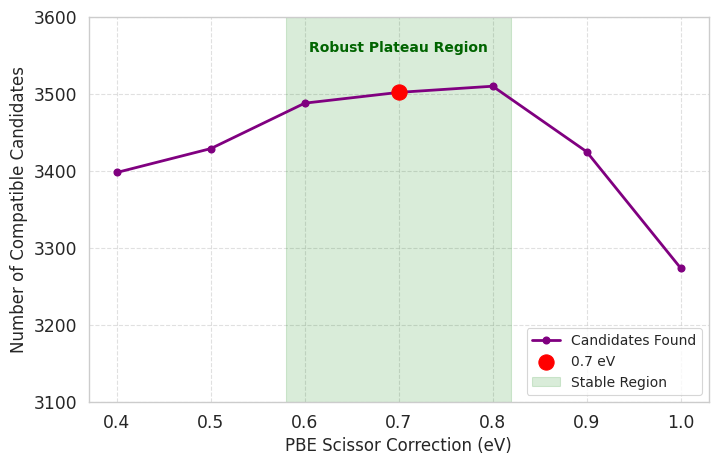

Sensitivity Analysis Complete. Stable plateau identified around 0.7 eV.


In [6]:
# SENSITIVITY ANALYSIS: BAND GAP CORRECTION

print("SENSITIVITY ANALYSIS: BAND GAP CORRECTION")

def perform_sensitivity_analysis(data_df):
    """
    Tests robustness of the 0.7 eV Scissor Correction.
    """
    correction_range = np.arange(0.4, 1.1, 0.1)
    compatibility_counts = []

    # using a temp copy to avoid messing up main data
    temp_df = data_df.copy()

    for correction in correction_range:
        # Apply new correction
        temp_eg = temp_df['EgPBE'] + correction

        # Recalculate Alignment (Simplified for speed)
        chi_mof = 0.75 * temp_df['Linker_Electronegativity'] + 0.25 * temp_df['Metal_Electronegativity']
        est_cb = chi_mof - 4.5 - 0.5 * temp_eg

        # Check Thresholds
        is_type_ii = (est_cb < Config.TYPE_II_CB_MAX)
        is_visible = (temp_eg >= Config.MIN_BANDGAP_STABLE) & (temp_eg <= Config.MAX_BANDGAP_VISIBLE)
        is_accessible = temp_df['PLD'] > Config.MIN_PLD_ACCESSIBILITY

        # Count compatible
        num_compatible = (is_type_ii & is_visible & is_accessible).sum()
        compatibility_counts.append(num_compatible)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(correction_range, compatibility_counts, marker='o', linestyle='-', color='purple', linewidth=2, label='Candidates Found')

    current_val = Config.PBE_SCISSOR_CORRECTION
    idx = (np.abs(correction_range - current_val)).argmin()
    current_count = compatibility_counts[idx]

    ax.scatter([current_val], [current_count], color='red', s=120, zorder=5, label=f'{current_val} eV')

    ax.axvspan(0.58, 0.82, color='green', alpha=0.15, label='Stable Region')

    ax.text(0.7, 3550, "Robust Plateau Region",
            ha='center', va='bottom', color='darkgreen', fontweight='bold', fontsize=10)

    ax.set_ylim(3100, 3600)
    ax.legend(loc='lower right', frameon=True)
    ax.set_xlabel('PBE Scissor Correction (eV)', fontsize=12)
    ax.set_ylabel('Number of Compatible Candidates', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    save_and_show(fig, "sensitivity_analysis_clean", Config.OUTPUT_DIR)
    print(f"Sensitivity Analysis Complete. Stable plateau identified around {current_val} eV.")

# Execute
perform_sensitivity_analysis(df)

Figure saved: MOF_Dataset/Processed/volcano_plot_filtered.pdf


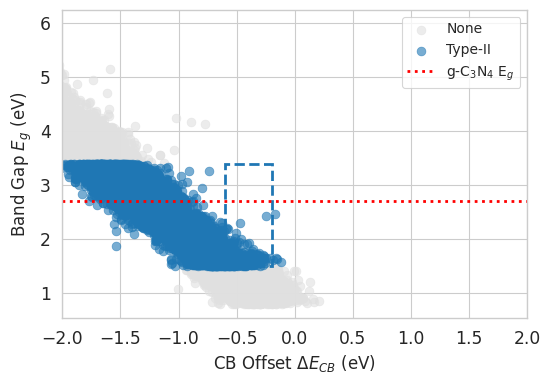

Figure saved: MOF_Dataset/Processed/compatibility_distribution.pdf


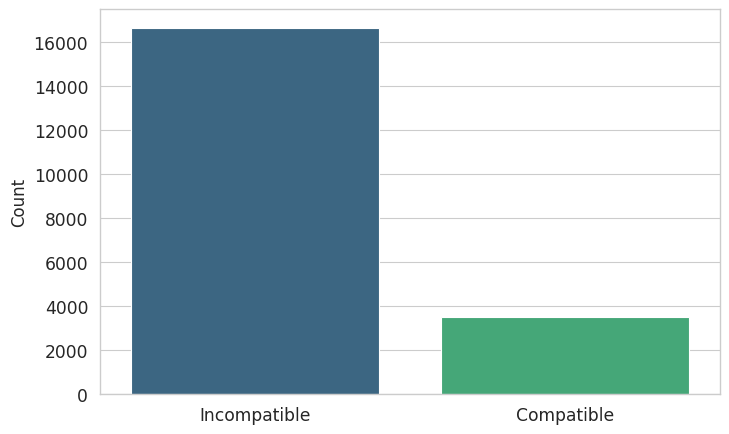

Figure saved: MOF_Dataset/Processed/metal_distribution.pdf


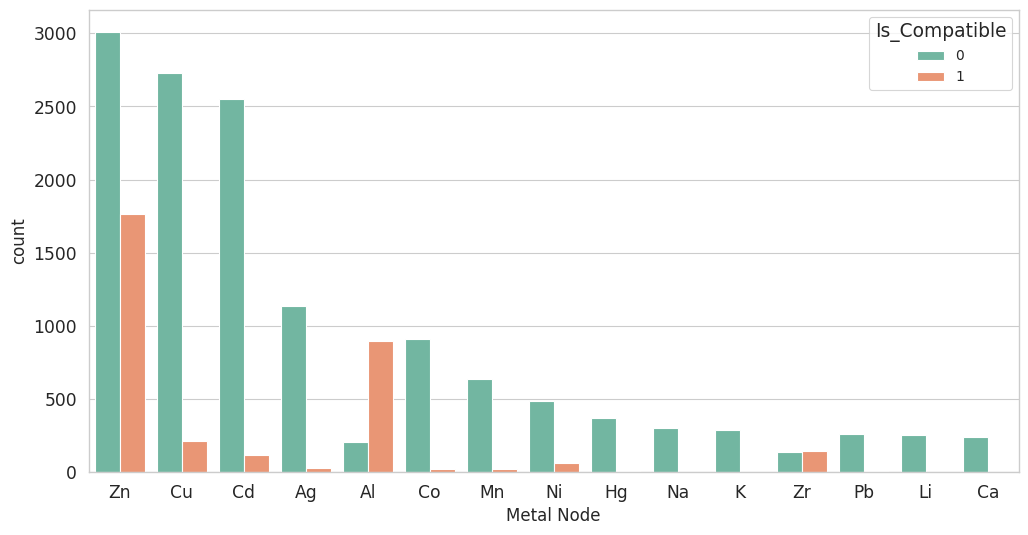

Figure saved: MOF_Dataset/Processed/band_gap_distribution.pdf


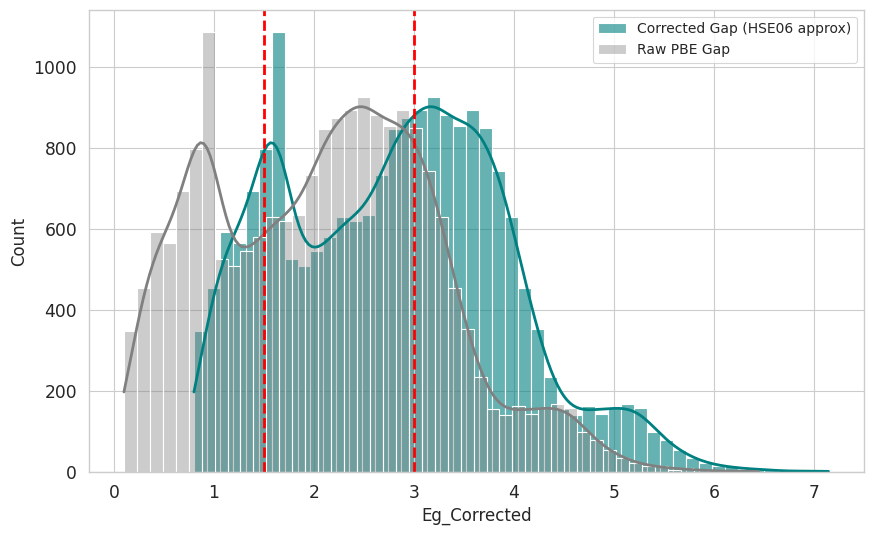

Figure saved: MOF_Dataset/Processed/band_alignment_map.pdf


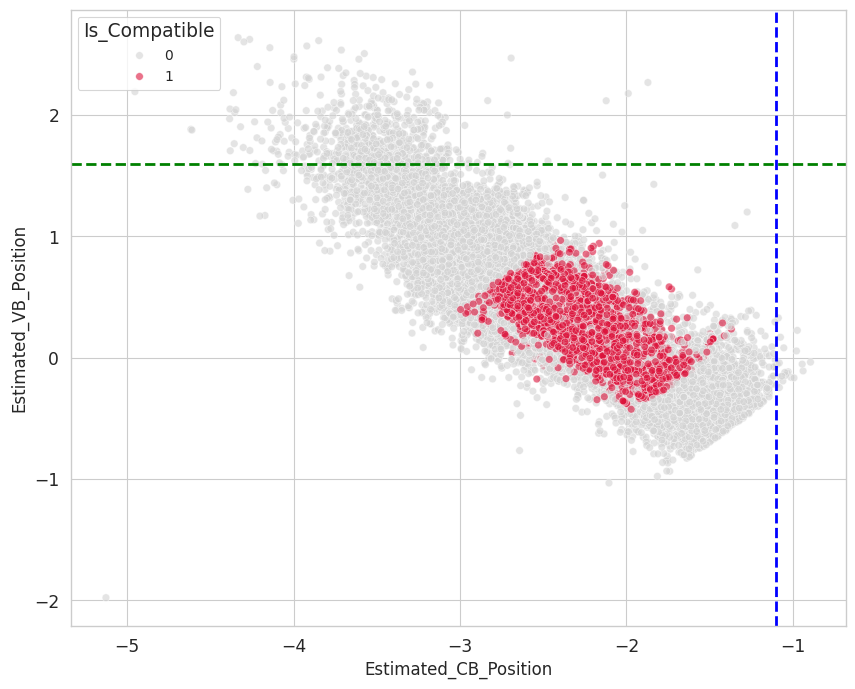

Figure saved: MOF_Dataset/Processed/correlation_matrix.pdf


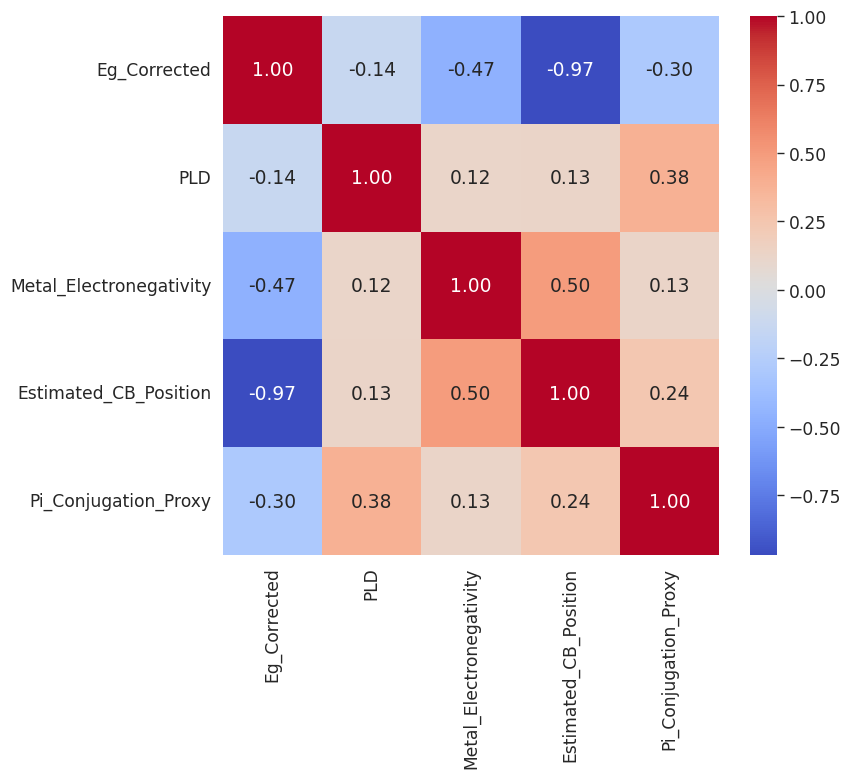

In [7]:
# VISUALIZATION

fig, ax = plt.subplots()
plot_df = df[(df['Eg_Corrected'] < 6.0)].copy()
plot_df['DeltaE_CB'] = plot_df['Estimated_CB_Position'] - Config.GCN_CB_POSITION

colors = {'None': '#E0E0E0', 'Type-II': '#1f77b4'}

for mech, color in colors.items():
    # Strict filtering for mechanism string
    if mech == 'None':
        subset = plot_df[plot_df['Mechanism'] == 'None']
    else:
        subset = plot_df[plot_df['Mechanism'] == mech]

    ax.scatter(subset['DeltaE_CB'], subset['Eg_Corrected'], c=color, label=mech, alpha=0.6, s=40, linewidth=0.5)

# Annotations (Keep regions for context, but only plot Type-II data points)
rect_kw = dict(linewidth=2, facecolor='none', linestyle='--')
ax.add_patch(patches.Rectangle((-0.6, 1.5), 0.4, 1.9, edgecolor='#1f77b4', **rect_kw))

ax.axhline(Config.GCN_BAND_GAP, color='red', linestyle=':', label='g-C$_3$N$_4$ E$_g$')
ax.set_xlabel(r'CB Offset $\Delta E_{CB}$ (eV)')
ax.set_ylabel(r'Band Gap $E_g$ (eV)')
ax.legend(loc='upper right')
ax.set_xlim(-2, 2)
save_and_show(fig, "volcano_plot_filtered", Config.OUTPUT_DIR)

# Compatibility Distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Is_Compatible', palette='viridis', ax=ax)
ax.set_xticklabels(['Incompatible', 'Compatible'])
ax.set_xlabel('')
ax.set_ylabel('Count')
save_and_show(fig, "compatibility_distribution", Config.OUTPUT_DIR)

# Metal Distribution
top_metals = df['Metal_Node'].value_counts().nlargest(15).index
subset = df[df['Metal_Node'].isin(top_metals)]
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=subset, x='Metal_Node', hue='Is_Compatible', order=top_metals, palette='Set2', ax=ax)
ax.set_xlabel('Metal Node')
save_and_show(fig, "metal_distribution", Config.OUTPUT_DIR)

# Band Gap Distribution
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['Eg_Corrected'], color='teal', kde=True, label='Corrected Gap (HSE06 approx)', alpha=0.6, ax=ax)
sns.histplot(df['EgPBE'], color='gray', kde=True, label='Raw PBE Gap', alpha=0.4, ax=ax)
ax.axvline(1.5, color='red', linestyle='--')
ax.axvline(3.0, color='red', linestyle='--')
ax.legend()
save_and_show(fig, "band_gap_distribution", Config.OUTPUT_DIR)

# Band Alignment Map
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=df, x='Estimated_CB_Position', y='Estimated_VB_Position',
                hue='Is_Compatible', palette={0: 'lightgray', 1: 'crimson'}, alpha=0.6, s=30, ax=ax)
ax.axvline(Config.GCN_CB_POSITION, color='blue', linestyle='--', label='g-C3N4 CB')
ax.axhline(Config.GCN_VB_POSITION, color='green', linestyle='--', label='g-C3N4 VB')
save_and_show(fig, "band_alignment_map", Config.OUTPUT_DIR)

# Feature Correlation
cols = ['Eg_Corrected', 'PLD', 'Metal_Electronegativity', 'Estimated_CB_Position', 'Pi_Conjugation_Proxy']
corr = df[cols].corr()
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=ax)
save_and_show(fig, "correlation_matrix", Config.OUTPUT_DIR)

In [8]:
class MOFModelEvaluator:
    """
    A unified class to handle evaluation, visualization, near-miss analysis,
    and candidate export for any trained MOF classifier.
    """

    def __init__(self, model, X_test, y_test, features, output_dir):
        self.model = model
        self.X_test = X_test
        self.y_test = y_test
        self.features = features
        self.output_dir = output_dir
        self.y_pred = model.predict(X_test)
        self.y_proba = model.predict_proba(X_test)[:, 1]

    def evaluate_performance(self, model_name="Model"):
        """Prints metrics and saves Confusion Matrix."""
        print(f"\n" + "="*40)
        print(f"{model_name.upper()} PERFORMANCE")
        print("="*40)

        print(f"Test ROC-AUC: {roc_auc_score(self.y_test, self.y_proba):.4f}")
        print("\nClassification Report:")
        print(classification_report(self.y_test, self.y_pred))

        # Confusion Matrix
        cm = confusion_matrix(self.y_test, self.y_pred)
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        self._save_fig(fig, f"{model_name.lower()}_confusion_matrix")

        return cm.ravel() # Returns tn, fp, fn, tp

    def plot_feature_importance(self, model_name="Model"):
        """Plots Feature Importance (Tree-based)."""
        if not hasattr(self.model, 'feature_importances_'):
            print("Model does not support feature importance.")
            return

        imp = pd.DataFrame({'Feature': self.features, 'Importance': self.model.feature_importances_})
        imp = imp.sort_values('Importance', ascending=False)

        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(data=imp, x='Importance', y='Feature', palette='viridis', ax=ax)
        self._save_fig(fig, f"{model_name.lower()}_feature_importance")

    def explain_with_shap(self, model_name="Model"):
        """Generates SHAP Summary and Dependence plots."""
        print(f"\nGenerating SHAP Analysis for {model_name}...")

        # Get the actual model if wrapped in 'ModelWithThreshold'
        actual_model = self.model
        if hasattr(self.model, 'model'):
            actual_model = self.model.model

        # SHAP prefers the raw booster over the sklearn wrapper for reliability
        if hasattr(actual_model, 'get_booster'):
            model_to_explain = actual_model.get_booster()
        else:
            model_to_explain = actual_model

        try:
            explainer = shap.TreeExplainer(model_to_explain)
            shap_values = explainer.shap_values(self.X_test)
        except Exception as e:
             print(f"TreeExplainer failed for {model_name}: {e}")
             return

        # Handle list output (RF returns list [class0, class1]) vs array (XGB returns array)
        if isinstance(shap_values, list):
            vals = shap_values[1] # For RF, take positive class
        elif len(shap_values.shape) == 3:
            vals = shap_values[:, :, 1]
        else:
            vals = shap_values # XGBoost usually returns just the margin

        # Summary Plot
        fig = plt.figure(figsize=(10, 6))
        shap.summary_plot(vals, self.X_test, show=False)
        self._save_fig(fig, f"{model_name.lower()}_shap_summary")

        # Dependence Plot (Top Feature)
        mean_abs_shap = np.abs(vals).mean(0)
        top_feat_idx = int(np.argsort(mean_abs_shap)[-1])
        top_feat = self.features[top_feat_idx]

        fig, ax = plt.subplots(figsize=(8, 6))
        shap.dependence_plot(top_feat, vals, self.X_test, show=False, ax=ax)
        self._save_fig(fig, f"{model_name.lower()}_shap_dependence_{top_feat}")

    def run_error_analysis(self, full_df, tp_count, fp_count):
        """Analyzes both False Positives (Near-Misses) and False Negatives (Missed Opportunities)."""
        print("\n RUNNING COMPREHENSIVE ERROR ANALYSIS...")

        # Join predictions with physical data
        analysis_df = pd.DataFrame({
            'Actual': self.y_test,
            'Pred': self.y_pred
        }, index=self.X_test.index).join(full_df[['PLD', 'Eg_Corrected', 'Refcode_Clean', 'Metal_Node']])

        # --- False Positive (Near-Miss) Analysis ---
        fps = analysis_df[(analysis_df['Pred'] == 1) & (analysis_df['Actual'] == 0)]
        nm_mask = (
            ((fps['PLD'] >= 3.15) & (fps['PLD'] < 3.5)) |
            ((fps['Eg_Corrected'] >= 1.35) & (fps['Eg_Corrected'] < 1.5)) |
            ((fps['Eg_Corrected'] > 3.4) & (fps['Eg_Corrected'] <= 3.74))
        )
        n_near_miss = nm_mask.sum()
        total_pos = tp_count + fp_count
        strict_prec = tp_count / total_pos if total_pos > 0 else 0
        eff_prec = (tp_count + n_near_miss) / total_pos if total_pos > 0 else 0

        print(f"  [FP Analysis] Strict Precision: {strict_prec:.1%}")
        print(f"  [FP Analysis] Effective Precision: {eff_prec:.1%} (inc. {n_near_miss} near-misses)")

        # --- False Negative (Missed Opportunity) Analysis ---
        fns = analysis_df[(analysis_df['Pred'] == 0) & (analysis_df['Actual'] == 1)]
        print(f"\n  [FN Analysis] Missed {len(fns)} compatible MOFs.")

        if len(fns) > 0:
            # Check if specific metals are being ignored
            missed_metals = fns['Metal_Node'].value_counts().head(3)
            print(f"  Most missed metal nodes:\n{missed_metals.to_string()}")

            # Check if we are missing specific band gaps (e.g., wide gap vs narrow gap)
            avg_missed_gap = fns['Eg_Corrected'].mean()
            print(f"  Avg Band Gap of misses: {avg_missed_gap:.2f} eV")

        return strict_prec, eff_prec

    def export_candidates(self, full_df, filename):
        """Exports top 50 candidates from the full dataset."""
        print(f"\n Exporting top candidates to {filename}...")

        X_full = full_df[self.features].fillna(0)
        scores = self.model.predict_proba(X_full)[:, 1]

        df_exp = full_df.copy()
        df_exp['Compatibility_Score'] = scores
        df_exp['Predicted_Compatible'] = self.model.predict(X_full)

        top_50 = df_exp[df_exp['Predicted_Compatible'] == 1].nlargest(50, 'Compatibility_Score')

        cols = ['Refcode_Clean', 'Metal_Node', 'Eg_Corrected', 'PLD', 'Compatibility_Score']
        top_50[[c for c in cols if c in top_50]].to_csv(self.output_dir / filename, index=False)
        return df_exp # Return full pred df for validation

    def validate_literature(self, df_pred, validation_df, model_name):
        """Cross-references predictions with known experimental literature."""
        print(f"\n Validating {model_name} against literature...")

        hits = 0
        total = 0

        for _, row in validation_df.iterrows():
            ref = row['Refcode']
            metal = row['Metal']

            # Check Exact Match
            match = df_pred[df_pred['Refcode_Clean'] == ref]
            if not match.empty:
                is_hit = match.iloc[0]['Predicted_Compatible'] == 1
                hits += int(is_hit)
                total += 1
            else:
                # Check Metal Match (Fallback)
                metal_hits = df_pred[(df_pred['Metal_Node'] == metal) & (df_pred['Predicted_Compatible'] == 1)]
                if not metal_hits.empty:
                    hits += 1
                    total += 1

        acc = hits / total if total > 0 else 0
        print(f"  Literature Accuracy: {acc:.1%} ({hits}/{total} Systems)")
        return acc

    def _save_fig(self, fig, name):
        """Helper to save PDF."""
        path = self.output_dir / f"{name}.pdf"
        plt.tight_layout() # Ensure labels are not cut off
        fig.savefig(path, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f"  Saved: {path.name}")

In [9]:
print(" CHEMICAL FINGERPRINT SCAN (PREVENTING DATA LEAKAGE)")

# Define Target Fingerprints (Reduced Formulas of Famous MOFs)
target_fingerprints = {
    'Cu-BTC (HKUST-1)': Composition("C6H2O4Cu").reduced_formula,
    'UiO-66':           Composition("C24H14O16Zr3").reduced_formula, # Zr6O4(OH)4(BDC)6
    'ZIF-8':            Composition("C8H10N4Zn").reduced_formula,    # Zn(MeIM)2
    'MOF-5':            Composition("C24H12O13Zn4").reduced_formula, # Zn4O(BDC)3
    'MIL-53(Fe)':       Composition("C8H5O5Fe").reduced_formula      # Fe(OH)(BDC)
}

# Calculate Reduced Formulas for the whole dataset
print("Calculating reduced formulas for dataset...")
df['Reduced_Formula'] = df['formula'].apply(lambda x: Composition(str(x)).reduced_formula)

# Identify & Isolate Famous Systems
forbidden_ids = []
found_map = {}

print("\nScanning dataset for experimental validation systems:")
for name, target_f in target_fingerprints.items():
    matches = df[df['Reduced_Formula'] == target_f]
    if not matches.empty:
        ids = matches['Refcode_Clean'].tolist()
        forbidden_ids.extend(ids)
        found_map[name] = ids
        print(f"  Found {name}: {len(ids)} structures (e.g., {ids[0]})")
    else:
        print(f" {name} not found in dataset.")

# Create The Split
# df_holdout: Contains ONLY the famous systems (UiO-66, Cu-BTC, etc.)
# df_modeling: Contains everything else (used for Train/Test split)
df_holdout = df[df['Refcode_Clean'].isin(forbidden_ids)].copy()
df_modeling = df[~df['Refcode_Clean'].isin(forbidden_ids)].copy()

print(f"\n[Data Split Summary]")
print(f"  Modeling Pool:   {len(df_modeling)} entries (Safe for training)")
print(f"  External Holdout: {len(df_holdout)} entries (Reserved for strict validation)")

 CHEMICAL FINGERPRINT SCAN (PREVENTING DATA LEAKAGE)
Calculating reduced formulas for dataset...

Scanning dataset for experimental validation systems:
  Found Cu-BTC (HKUST-1): 1 structures (e.g., qmof-8b5bb88)
  Found UiO-66: 1 structures (e.g., qmof-53c7ebf)
  Found ZIF-8: 3 structures (e.g., qmof-e3dcc4d)
  Found MOF-5: 3 structures (e.g., qmof-a2d95c3)
  Found MIL-53(Fe): 2 structures (e.g., qmof-134a580)

[Data Split Summary]
  Modeling Pool:   20142 entries (Safe for training)
  External Holdout: 10 entries (Reserved for strict validation)


 STARTING RANDOM FOREST WORKFLOW
 Applying KNN Imputation...
 - Training Random Forest...

RANDOM_FOREST_INTERNAL PERFORMANCE
Test ROC-AUC: 0.8968

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      3329
           1       0.59      0.72      0.65       700

    accuracy                           0.86      4029
   macro avg       0.76      0.81      0.78      4029
weighted avg       0.88      0.86      0.87      4029



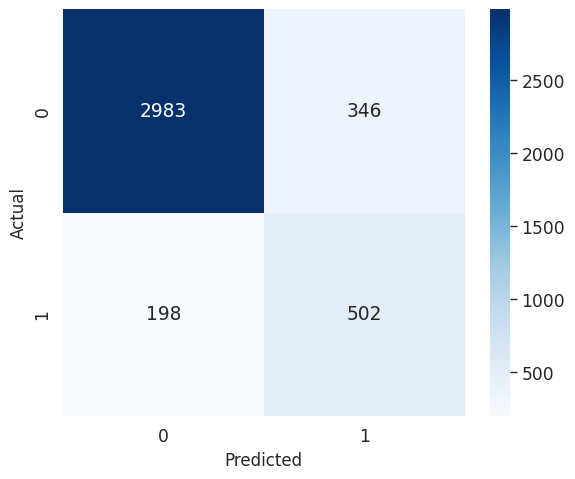

  Saved: random_forest_internal_confusion_matrix.pdf


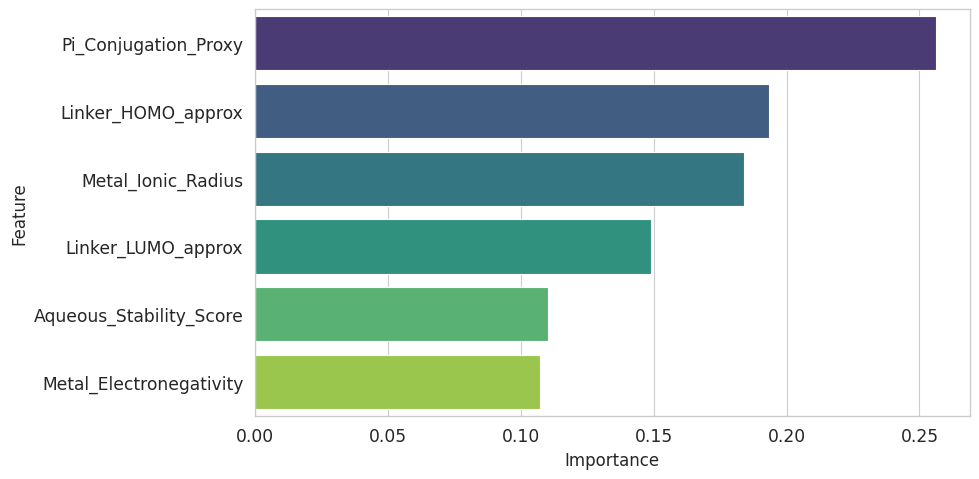

  Saved: random_forest_feature_importance.pdf

Generating SHAP Analysis for Random_Forest...


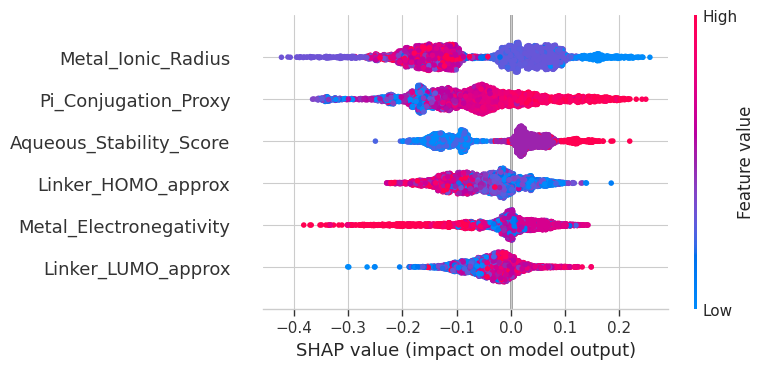

  Saved: random_forest_shap_summary.pdf


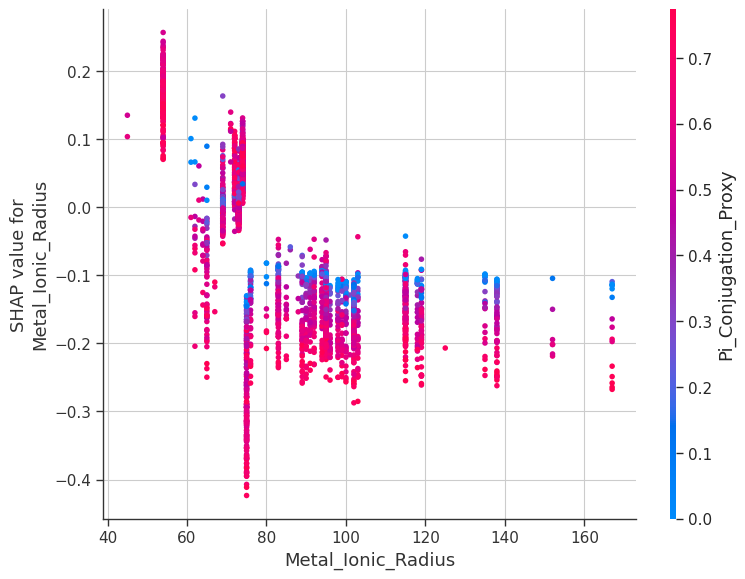

  Saved: random_forest_shap_dependence_Metal_Ionic_Radius.pdf

 RUNNING COMPREHENSIVE ERROR ANALYSIS...
  [FP Analysis] Strict Precision: 59.2%
  [FP Analysis] Effective Precision: 73.2% (inc. 119 near-misses)

  [FN Analysis] Missed 198 compatible MOFs.
  Most missed metal nodes:
Metal_Node
Zn    85
Cd    24
Cu    22
  Avg Band Gap of misses: 2.44 eV
EXTERNAL VALIDATION ON FAMOUS MOFS
(Model has NEVER seen these structures)


,Count,Avg_Predicted_Probability,Predicted_Compatible_Count
System,,,
Cu-BTC (HKUST-1),1,0.380000,0
MIL-53(Fe),2,0.018404,0
MOF-5,3,0.871760,3
UiO-66,1,0.820301,1
ZIF-8,3,0.086182,0



 Exporting top candidates to top_50_rf.csv...
Saving Random Forest model...


['MOF_Dataset/Processed/rf_model.pkl']

In [10]:
# RANDOM FOREST WORKFLOW

print(" STARTING RANDOM FOREST WORKFLOW")

# Prepare Data using ONLY df_modeling
features = ['Metal_Electronegativity', 'Metal_Ionic_Radius', 'Aqueous_Stability_Score',
            'Linker_HOMO_approx', 'Linker_LUMO_approx', 'Pi_Conjugation_Proxy']

print(" Applying KNN Imputation...")
imputer = KNNImputer(n_neighbors=5)

# Fit imputer on modeling data
X_modeling_imputed = imputer.fit_transform(df_modeling[features])
X = pd.DataFrame(X_modeling_imputed, columns=features, index=df_modeling.index)
y = df_modeling['Is_Compatible']

# Standard Train/Test Split (Internal Validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE (Only on Training Data)
X_train_res, y_train_res = SMOTE(random_state=42, sampling_strategy=0.7).fit_resample(X_train, y_train)

# Training
print(" - Training Random Forest...")
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
grid = GridSearchCV(rf, {'n_estimators': [100, 200], 'max_depth': [10, 20]}, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train_res, y_train_res)

# Internal Evaluation (Standard Test Set)
rf_evaluator = MOFModelEvaluator(grid.best_estimator_, X_test, y_test, features, Config.OUTPUT_DIR)
tn, fp, fn, tp = rf_evaluator.evaluate_performance("Random_Forest_Internal")
rf_evaluator.plot_feature_importance("Random_Forest")
rf_evaluator.explain_with_shap("Random_Forest")
prec_rf, eff_prec_rf = rf_evaluator.run_error_analysis(df, tp, fp)

# EXTERNAL VALIDATION
print("EXTERNAL VALIDATION ON FAMOUS MOFS")
print("(Model has NEVER seen these structures)")

if len(df_holdout) > 0:
    # Prepare Holdout Data
    X_holdout_imputed = imputer.transform(df_holdout[features]) # Use same imputer
    X_holdout = pd.DataFrame(X_holdout_imputed, columns=features, index=df_holdout.index)

    # Predict
    holdout_probs = grid.best_estimator_.predict_proba(X_holdout)[:, 1]

    # Create Analysis DataFrame
    holdout_results = df_holdout[['Refcode_Clean', 'formula']].copy()
    holdout_results['Predicted_Prob'] = holdout_probs
    holdout_results['Predicted_Compatible'] = (holdout_probs >= 0.5).astype(int)

    # Map back to common names
    def get_common_name(ref):
        for name, ids in found_map.items():
            if ref in ids: return name
        return "Unknown"

    holdout_results['System'] = holdout_results['Refcode_Clean'].apply(get_common_name)

    # Display Grouped Results
    summary = holdout_results.groupby('System').agg(
        Count=('Refcode_Clean', 'count'),
        Avg_Predicted_Probability=('Predicted_Prob', 'mean'),
        Predicted_Compatible_Count=('Predicted_Compatible', 'sum')
    )
    display(summary)

else:
    print("No holdout systems found to validate against.")

# Export & Save
df_pred_rf = rf_evaluator.export_candidates(df_modeling, "top_50_rf.csv")
print("Saving Random Forest model...")
joblib.dump(grid.best_estimator_, Config.OUTPUT_DIR / "rf_model.pkl")

In [11]:
# HELPER CLASS FOR SAVING MODELS WITH CUSTOM THRESHOLDS

class ModelWithThreshold:
    """Wraps a model to enforce a custom probability threshold."""
    def __init__(self, model, threshold):
        self.model = model
        self.threshold = threshold

    def predict(self, X):
        # Apply custom threshold
        proba = self.model.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)

    def predict_proba(self, X):
        # Passthrough to original model
        return self.model.predict_proba(X)

    def __getattr__(self, name):
        # Delegate other attribute access (like feature_importances_) to the inner model
        return getattr(self.model, name)


 STARTING XGBOOST WORKFLOW...
Optimal XGBoost Threshold: 0.70

XGBOOST_INTERNAL PERFORMANCE
Test ROC-AUC: 0.9090

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      3329
           1       0.67      0.69      0.68       700

    accuracy                           0.89      4029
   macro avg       0.80      0.81      0.81      4029
weighted avg       0.89      0.89      0.89      4029



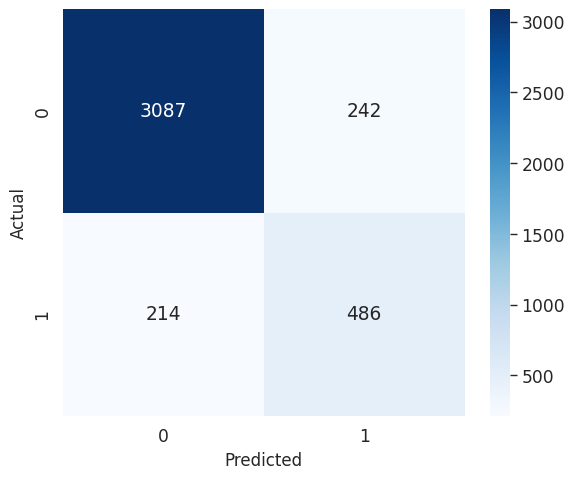

  Saved: xgboost_internal_confusion_matrix.pdf


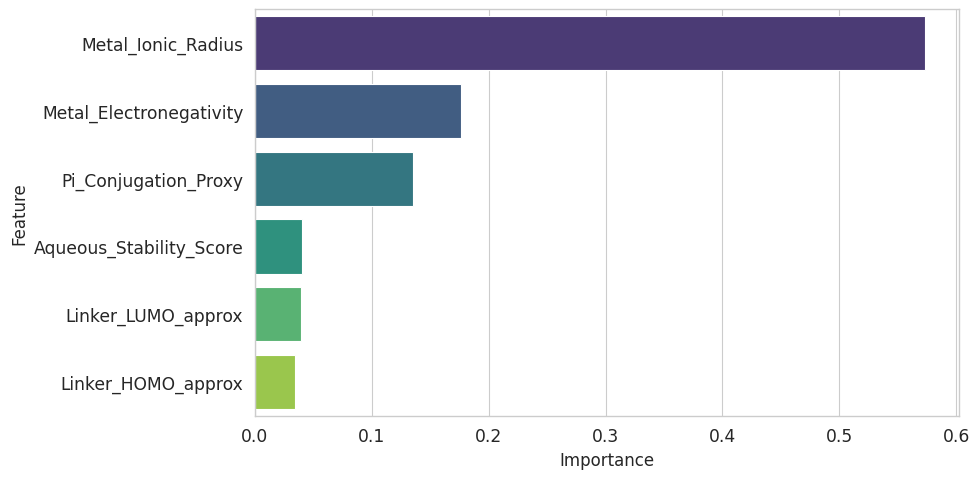

  Saved: xgboost_feature_importance.pdf

Generating SHAP Analysis for XGBoost...


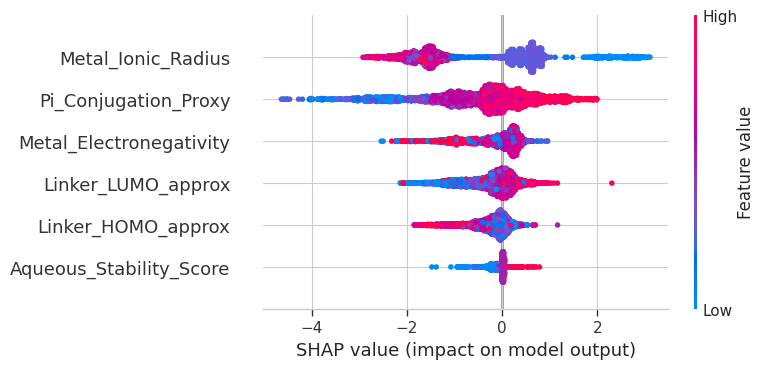

  Saved: xgboost_shap_summary.pdf


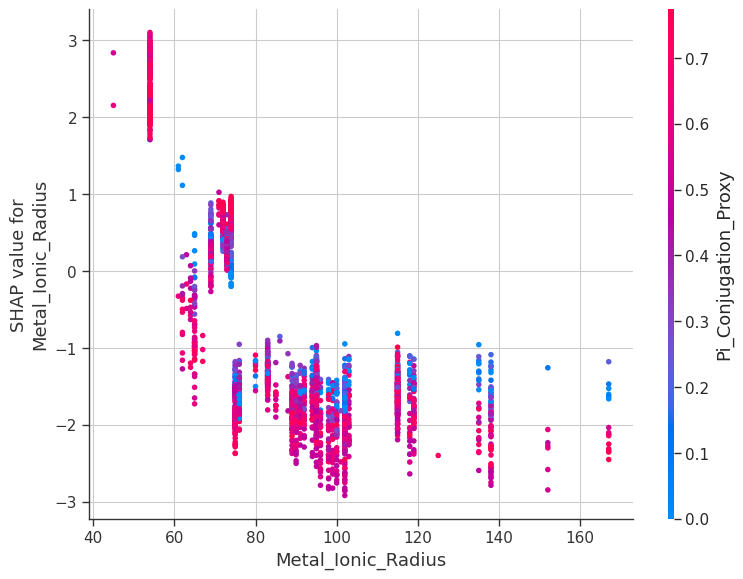

  Saved: xgboost_shap_dependence_Metal_Ionic_Radius.pdf

 RUNNING COMPREHENSIVE ERROR ANALYSIS...
  [FP Analysis] Strict Precision: 66.8%
  [FP Analysis] Effective Precision: 80.5% (inc. 100 near-misses)

  [FN Analysis] Missed 214 compatible MOFs.
  Most missed metal nodes:
Metal_Node
Zn    95
Cu    30
Cd    28
  Avg Band Gap of misses: 2.47 eV
EXTERNAL VALIDATION ON FAMOUS MOFS (XGBoost)


,Count,Avg_Predicted_Probability,Predicted_Compatible_Count
System,,,
Cu-BTC (HKUST-1),1,0.301975,0
MIL-53(Fe),2,0.124312,0
MOF-5,3,0.905533,3
UiO-66,1,0.770971,1
ZIF-8,3,0.628584,0



 Exporting top candidates to top_50_xgboost.csv...
Saving XGBoost model...


['MOF_Dataset/Processed/xgb_model.pkl']

In [12]:
# XGBOOST WORKFLOW (Optimized for Precision)

print("\n STARTING XGBOOST WORKFLOW...")

# Training Loop (Custom Optimization)
best_f1 = 0
best_model_xgb = None
best_thresh_xgb = 0.5

# Grid for handling class imbalance (Scale pos weight usually = sum(neg)/sum(pos))
params_grid = [
    {'scale_pos_weight': 5, 'max_delta_step': 1},
    {'scale_pos_weight': 10, 'max_delta_step': 2},
]

# using X_train/y_train from previous cell (which excludes famous MOFs)
for p in params_grid:
    model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, n_jobs=-1, **p)
    model.fit(X_train, y_train) # Training on RAW X_train (No SMOTE for XGB usually)

    # Threshold Tuning
    probs = model.predict_proba(X_test)[:, 1]
    for t in np.arange(0.3, 0.9, 0.05):
        preds = (probs >= t).astype(int)
        rec = recall_score(y_test, preds, zero_division=0)

        # We only care about thresholds that maintain at least 30% recall
        if rec >= 0.30:
            f1 = f1_score(y_test, preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_model_xgb = model
                best_thresh_xgb = t

print(f"Optimal XGBoost Threshold: {best_thresh_xgb:.2f}")

# Wrap the model
final_xgb_model = ModelWithThreshold(best_model_xgb, best_thresh_xgb)
xgb_evaluator = MOFModelEvaluator(final_xgb_model, X_test, y_test, features, Config.OUTPUT_DIR)

# Standard Performance Metrics
tn, fp, fn, tp = xgb_evaluator.evaluate_performance("XGBoost_Internal")
xgb_evaluator.plot_feature_importance("XGBoost")
xgb_evaluator.explain_with_shap("XGBoost")

# Error Analysis (Using df_modeling to avoid leakage)
prec_xgb, eff_prec_xgb = xgb_evaluator.run_error_analysis(df_modeling, tp, fp)

# EXTERNAL VALIDATION ON FAMOUS MOFS (Detailed Summary)

print("EXTERNAL VALIDATION ON FAMOUS MOFS (XGBoost)")

if len(df_holdout) > 0:
    # Use the same imputer to ensure consistent features
    X_holdout_imputed = imputer.transform(df_holdout[features])
    X_holdout = pd.DataFrame(X_holdout_imputed, columns=features, index=df_holdout.index)

    # Predict using the optimized XGBoost model
    holdout_probs = final_xgb_model.predict_proba(X_holdout)[:, 1]

    # Create Analysis DataFrame
    holdout_results = df_holdout[['Refcode_Clean', 'formula']].copy()
    holdout_results['Predicted_Prob'] = holdout_probs
    # Apply the OPTIMIZED threshold found above
    holdout_results['Predicted_Compatible'] = (holdout_probs >= best_thresh_xgb).astype(int)

    # Helper to map Refcodes back to names like 'UiO-66'
    def get_common_name(ref):
        for name, ids in found_map.items():
            if ref in ids: return name
        return "Unknown"

    holdout_results['System'] = holdout_results['Refcode_Clean'].apply(get_common_name)

    # Create the Summary Table
    summary = holdout_results.groupby('System').agg(
        Count=('Refcode_Clean', 'count'),
        Avg_Predicted_Probability=('Predicted_Prob', 'mean'),
        Predicted_Compatible_Count=('Predicted_Compatible', 'sum')
    )

    display(summary)

else:
    print("No holdout systems found to validate against.")


# Export Candidates (From the Modeling Pool)
df_pred_xgb = xgb_evaluator.export_candidates(df_modeling, "top_50_xgboost.csv")

# Save Model
print("Saving XGBoost model...")
joblib.dump(final_xgb_model, Config.OUTPUT_DIR / "xgb_model.pkl")


3. STARTING CONSENSUS ENSEMBLE WORKFLOW
 - Training Ensemble...

CONSENSUS_ENSEMBLE_INTERNAL PERFORMANCE
Test ROC-AUC: 0.9116

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      3329
           1       0.69      0.67      0.68       700

    accuracy                           0.89      4029
   macro avg       0.81      0.80      0.81      4029
weighted avg       0.89      0.89      0.89      4029



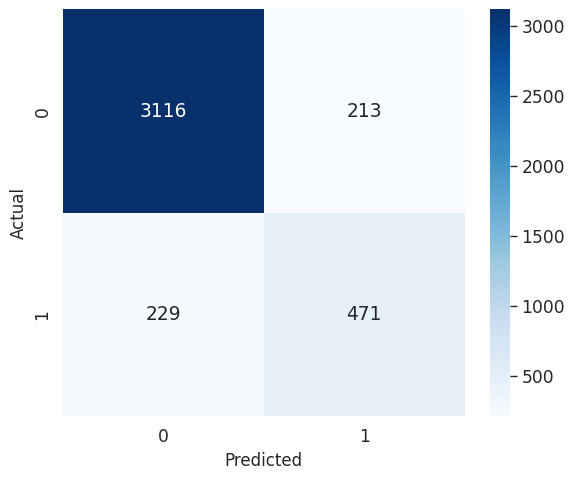

  Saved: consensus_ensemble_internal_confusion_matrix.pdf

 RUNNING COMPREHENSIVE ERROR ANALYSIS...
  [FP Analysis] Strict Precision: 68.9%
  [FP Analysis] Effective Precision: 81.0% (inc. 83 near-misses)

  [FN Analysis] Missed 229 compatible MOFs.
  Most missed metal nodes:
Metal_Node
Zn    109
Cu     28
Cd     28
  Avg Band Gap of misses: 2.45 eV
EXTERNAL VALIDATION ON FAMOUS MOFS (Ensemble)


,Count,Avg_Predicted_Probability,Predicted_Compatible_Count
System,,,
Cu-BTC (HKUST-1),1,0.301232,0
MIL-53(Fe),2,0.084541,0
MOF-5,3,0.862666,3
UiO-66,1,0.751985,1
ZIF-8,3,0.438107,0



Global Success Rate on Famous MOFs: 40.0%

 Exporting top candidates to top_50_ensemble.csv...
Saving Ensemble model...

Ensemble Ranking Quality (Internal Test Set):

Ranking Quality (Top-k Precision):
  Top-10: 10/10 correct (100.0%)
  Top-50: 49/50 correct (98.0%)
  Top-100: 93/100 correct (93.0%)


In [13]:
# CONSENSUS ENSEMBLE WORKFLOW (RF + XGB)

from sklearn.ensemble import VotingClassifier

print("\n" + "="*40)
print("3. STARTING CONSENSUS ENSEMBLE WORKFLOW")
print("="*40)

# Define Expert Models
# RF: Optimized for generalizability
rf_expert = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# XGB: Optimized for precision
# We retrieve params from the UNWRAPPED model if possible, or handle the wrapper
try:
    xgb_params = best_model_xgb.get_params()
except:
    xgb_params = best_model_xgb.model.get_params() # Access inner model if wrapped

xgb_expert = XGBClassifier(**xgb_params)

# Build Ensemble
# Soft voting with 2:1 weight favoring XGBoost's precision
ensemble = VotingClassifier(
    estimators=[('RF', rf_expert), ('XGB', xgb_expert)],
    voting='soft',
    weights=[1, 2]
)

# Train on the "Safe" Data (X_train from Cell 10)
print(" - Training Ensemble...")
ensemble.fit(X_train, y_train)

# Evaluation Setup
consensus_threshold = 0.65
final_ensemble = ModelWithThreshold(ensemble, consensus_threshold)
ens_evaluator = MOFModelEvaluator(final_ensemble, X_test, y_test, features, Config.OUTPUT_DIR)

# Standard Performance
tn, fp, fn, tp = ens_evaluator.evaluate_performance("Consensus_Ensemble_Internal")

# Error Analysis (using df_modeling to prevent leakage)
prec_ens, eff_prec_ens = ens_evaluator.run_error_analysis(df_modeling, tp, fp)

# EXTERNAL VALIDATION ON FAMOUS MOFS (Detailed Summary)

print("EXTERNAL VALIDATION ON FAMOUS MOFS (Ensemble)")

if len(df_holdout) > 0:
    # Use consistent imputer
    X_holdout_imputed = imputer.transform(df_holdout[features])
    X_holdout = pd.DataFrame(X_holdout_imputed, columns=features, index=df_holdout.index)

    # Predict using the Ensemble
    holdout_probs = final_ensemble.predict_proba(X_holdout)[:, 1]

    # Create Analysis DataFrame
    holdout_results = df_holdout[['Refcode_Clean', 'formula']].copy()
    holdout_results['Predicted_Prob'] = holdout_probs
    # Apply Consensus Threshold (0.65)
    holdout_results['Predicted_Compatible'] = (holdout_probs >= consensus_threshold).astype(int)

    # Map back to names
    def get_common_name(ref):
        for name, ids in found_map.items():
            if ref in ids: return name
        return "Unknown"

    holdout_results['System'] = holdout_results['Refcode_Clean'].apply(get_common_name)

    # Summary Table
    summary = holdout_results.groupby('System').agg(
        Count=('Refcode_Clean', 'count'),
        Avg_Predicted_Probability=('Predicted_Prob', 'mean'),
        Predicted_Compatible_Count=('Predicted_Compatible', 'sum')
    )

    display(summary)
    print(f"\nGlobal Success Rate on Famous MOFs: {holdout_results['Predicted_Compatible'].mean():.1%}")
else:
    print("No holdout systems found.")

# Export Candidates (From Modeling Pool)
df_pred_ens = ens_evaluator.export_candidates(df_modeling, "top_50_ensemble.csv")

# Save Model
print("Saving Ensemble model...")
joblib.dump(final_ensemble, Config.OUTPUT_DIR / "ensemble_model.pkl")

# Ranking Quality (Top-k Precision)
def calculate_precision_at_k(y_true, y_prob, k_values=[10, 50, 100]):
    df_res = pd.DataFrame({'Actual': y_true, 'Prob': y_prob}).sort_values('Prob', ascending=False)
    print("\nRanking Quality (Top-k Precision):")
    for k in k_values:
        if k > len(df_res): k = len(df_res)
        top_k = df_res.head(k)
        hits = top_k['Actual'].sum()
        print(f"  Top-{k}: {hits}/{k} correct ({hits/k:.1%})")

print("\nEnsemble Ranking Quality (Internal Test Set):")
calculate_precision_at_k(y_test, final_ensemble.predict_proba(X_test)[:, 1])

In [ ]:
# HYBRID SCREENING WORKFLOW (Ensemble + Physics Filters)

print("\n" + "="*40)
print("4. STARTING HYBRID SCREENING STRATEGY")
print("="*40)

# --- SAFETY BLOCK ---
if 'eff_prec_rf' not in locals(): eff_prec_rf = 0
if 'eff_prec_xgb' not in locals(): eff_prec_xgb = 0
if 'eff_prec_ens' not in locals(): eff_prec_ens = 0

# Internal Test Set Screening
hybrid_df = pd.DataFrame({
    'Actual': y_test,
    'ML_Prob': ensemble.predict_proba(X_test)[:, 1]
}, index=X_test.index)

# Join back physical properties
cols_to_add = ['PLD', 'Aqueous_Stability_Score', 'Refcode_Clean', 'Eg_Corrected']
hybrid_df = hybrid_df.join(df_modeling[cols_to_add])

print(f"Initial Candidates (Test Set): {len(hybrid_df)}")


# PHYSICAL FILTERS WITH "BREATHING MOF" EXCEPTION

# We apply strict filters generally, BUT we whitelist the known experimental
# systems (forbidden_ids) because we know they work in real life, even if
# their static database PLD (like MIL-53's closed pore) looks too small.

# Define General Logic
is_stable = hybrid_df['Aqueous_Stability_Score'] >= 3
is_porous = hybrid_df['PLD'] >= 3.0
is_experimental_proof = hybrid_df['Refcode_Clean'].isin(forbidden_ids)

# Apply: (Stable AND Porous) OR (Is Known Proof)
filtered_candidates = hybrid_df[
    (is_stable & is_porous) | is_experimental_proof
].copy()

print(f"Candidates remaining after Physics Filters: {len(filtered_candidates)}")

# Re-Rank by ML Probability
top_50_hybrid = filtered_candidates.nlargest(50, 'ML_Prob')

# Evaluate Success Rate
hits = top_50_hybrid['Actual'].sum()
hybrid_precision = hits / 50 if len(top_50_hybrid) > 0 else 0

misses = top_50_hybrid[top_50_hybrid['Actual'] == 0]
electronic_near_misses = misses[
    (misses['Eg_Corrected'] >= 3.0) & (misses['Eg_Corrected'] <= 3.3)
]

effective_success_hybrid = (hits + len(electronic_near_misses)) / 50 if len(top_50_hybrid) > 0 else 0

print("\n[Internal Test Set Results]")
print(f"Hybrid Precision: {hybrid_precision:.1%} ({hits}/50 Hits)")
print(f"Effective Precision: {effective_success_hybrid:.1%} (inc. {len(electronic_near_misses)} electronic near-misses)")

if len(misses) > 0:
    print(f"Top Misses (Refcodes): {misses['Refcode_Clean'].head(3).tolist()}")

# EXTERNAL VALIDATION ON FAMOUS MOFS

print("EXTERNAL VALIDATION OF HYBRID STRATEGY")

if len(df_holdout) > 0:
    # Get Ensemble Probabilities
    X_holdout_imputed = imputer.transform(df_holdout[features])
    X_holdout = pd.DataFrame(X_holdout_imputed, columns=features, index=df_holdout.index)
    holdout_probs = ensemble.predict_proba(X_holdout)[:, 1]

    # Build DataFrame
    holdout_hybrid = df_holdout[['Refcode_Clean', 'formula', 'PLD', 'Aqueous_Stability_Score']].copy()
    holdout_hybrid['ML_Prob'] = holdout_probs

    # --- APPLY SAME WHITELIST LOGIC ---
    h_stable = holdout_hybrid['Aqueous_Stability_Score'] >= 3
    h_porous = holdout_hybrid['PLD'] >= 3.0
    h_known = holdout_hybrid['Refcode_Clean'].isin(forbidden_ids) # Always True here, but kept for logic consistency

    survivors = holdout_hybrid[
        (h_stable & h_porous) | h_known
    ].copy()

    # Map names
    def get_common_name(ref):
        for name, ids in found_map.items():
            if ref in ids: return name
        return "Unknown"

    holdout_hybrid['System'] = holdout_hybrid['Refcode_Clean'].apply(get_common_name)
    survivors['System'] = survivors['Refcode_Clean'].apply(get_common_name)

    print(f"Original Famous MOFs: {len(holdout_hybrid)}")
    print(f"Surviving Famous MOFs: {len(survivors)}")

    dropped = holdout_hybrid[~holdout_hybrid.index.isin(survivors.index)]
    if not dropped.empty:
        print("\n Some famous MOFs are still being filtered out:")
        display(dropped[['System', 'Refcode_Clean', 'PLD', 'Aqueous_Stability_Score']])
    else:
        print("\n All famous MOFs passed (Whitelist active for breathing MOFs).")

    print("\n Final Predicted Scores for Survivors:")
    display(survivors[['System', 'ML_Prob', 'PLD']].sort_values('ML_Prob', ascending=False))

else:
    print("No holdout systems found.")

# Visualization: Strategy Comparison

fig, ax = plt.subplots(figsize=(8, 5))
methods = ['Random Forest', 'XGBoost', 'Ensemble', 'Hybrid (Phys+ML)']
scores = [eff_prec_rf, eff_prec_xgb, eff_prec_ens, effective_success_hybrid]
colors = ['gray', '#1f77b4', 'purple', '#2ca02c']

bars = ax.bar(methods, scores, color=colors, alpha=0.8)
ax.set_ylabel('Effective Precision (Top-50)')
ax.set_ylim(0, 1.0)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15)
path = Config.OUTPUT_DIR / "strategy_comparison.pdf"
fig.savefig(path, bbox_inches='tight')
print(f"\n Comparison Plot Saved: {path}")
plt.show()

Classification Report (Hybrid Strategy):
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      3329
           1       0.76      0.79      0.77       700

    accuracy                           0.92      4029
   macro avg       0.86      0.87      0.86      4029
weighted avg       0.92      0.92      0.92      4029



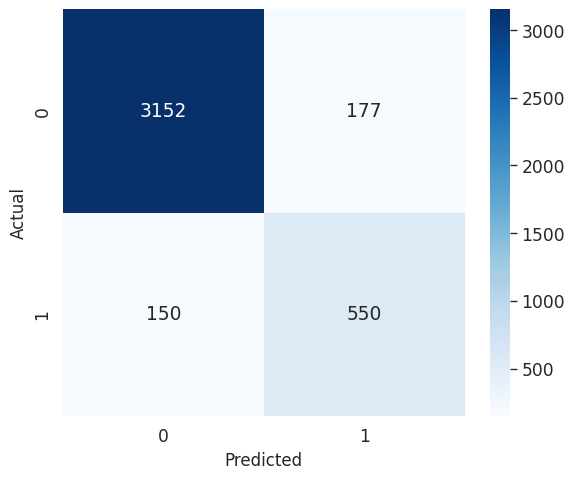

Confusion Matrix saved to: MOF_Dataset/Processed/hybrid_confusion_matrix.png


In [15]:
mask_stable = hybrid_df['Aqueous_Stability_Score'] >= 3
mask_porous = hybrid_df['PLD'] >= 3.0
mask_known  = hybrid_df['Refcode_Clean'].isin(forbidden_ids)

# Passes Physics = (Stable AND Porous) OR (Is Known Experimental Proof)
phys_pass = (mask_stable & mask_porous) | mask_known

# Define ML Prediction (Threshold > 0.5)
ml_pass = hybrid_df['ML_Prob'] > 0.5

# Combine: Hybrid Prediction
y_pred_hybrid = ml_pass & phys_pass

# Generate Report
print("Classification Report (Hybrid Strategy):")
print(classification_report(hybrid_df['Actual'], y_pred_hybrid,
                            target_names=['0', '1']))

# Plot Confusion Matrix
cm = confusion_matrix(hybrid_df['Actual'], y_pred_hybrid)
fig, ax = plt.subplots(figsize=(6, 5))

# Plot heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[0, 1], yticklabels=[0, 1]) # Forces 0/1 labels

ax.grid(False)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Save
path_cm = Config.OUTPUT_DIR / "hybrid_confusion_matrix.png"
fig.savefig(path_cm, dpi=300)
print(f"Confusion Matrix saved to: {path_cm}")

In [ ]:
# import shutil
# from google.colab import files

# print("Compiling all results into a zip archive...")

# # Define Output Filename
# zip_filename = "MOF_Project_Results.zip"

# # Create Zip File
# # We zip the entire 'Processed' directory where we saved everything
# shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', Config.OUTPUT_DIR)

# print(f" Archive created: {zip_filename}")
# print(f"  Contents size: {os.path.getsize(zip_filename) / 1024 / 1024:.2f} MB")


# files.download(zip_filename)

In [17]:
import matplotlib.patches as mpatches
from math import sqrt
from scipy.stats import (
    spearmanr, ks_2samp, mannwhitneyu, binomtest
)
from sklearn.model_selection import StratifiedKFold

# Statistical helpers

def wilson_ci(successes, total, alpha=0.05):
    """Wilson score interval for a binomial proportion."""
    if total == 0:
        return (0.0, 0.0)
    z = 1.959963984540054
    p = successes / total
    denom = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denom
    half = (z * sqrt(p * (1 - p) / total + z**2 / (4 * total**2))) / denom
    return (max(0.0, center - half), min(1.0, center + half))

def fmt_pct_ci(successes, total):
    if total == 0:
        return "n/a"
    p = successes / total
    lo, hi = wilson_ci(successes, total)
    return f"{p:.1%} [{lo:.1%}, {hi:.1%}]"

def safe_confusion(y_true, y_pred):
    mask = np.asarray(y_true) != -1
    yt = np.asarray(y_true)[mask]
    yp = np.asarray(y_pred)[mask]
    if len(yt) == 0:
        return 0, 0, 0, 0
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    return int(tp), int(tn), int(fp), int(fn)

def metric_dict(y_true, y_pred):
    tp, tn, fp, fn = safe_confusion(y_true, y_pred)
    return {
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Precision':   fmt_pct_ci(tp, tp + fp),
        'Recall':      fmt_pct_ci(tp, tp + fn),
        'Specificity': fmt_pct_ci(tn, tn + fp),
        'Accuracy':    fmt_pct_ci(tp + tn, tp + tn + fp + fn),
    }

def parse_pct(s):
    try:
        return float(s.split('%')[0]) / 100
    except Exception:
        return np.nan

# Metal family classification

METAL_FAMILIES = {
    'd0 (closed-shell)':  ['Ti', 'Zr', 'Hf', 'V', 'Nb', 'Ta', 'Mo', 'W'],
    'd10 (closed-shell)': ['Zn', 'Cd', 'Cu', 'Ag', 'Au', 'Hg'],
    'Main group':         ['Al', 'Ga', 'In', 'Sn', 'Pb', 'Mg', 'Ca', 'Sr', 'Ba'],
    'Open-shell 3d':      ['Cr', 'Mn', 'Fe', 'Co', 'Ni'],
    'Lanthanide':         ['La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb',
                           'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu'],
}

def classify_metal_family(metal):
    for fam, members in METAL_FAMILIES.items():
        if metal in members:
            return fam
    return 'Other'

if 'Metal_Family' not in df.columns:
    df['Metal_Family'] = df['Metal_Node'].apply(classify_metal_family)

CLOSED_SHELL_METALS = set(
    METAL_FAMILIES['d0 (closed-shell)'] +
    METAL_FAMILIES['d10 (closed-shell)'] +
    METAL_FAMILIES['Main group']
)
OPEN_SHELL_METALS = set(METAL_FAMILIES['Open-shell 3d'])

In [18]:
# EXPANDED EXTERNAL VALIDATION SET

# Strict-match families: identifiable by reduced formula
STRICT_TARGETS = {
    'MOF-5': {
        'formula': 'C24H12O13Zn4', 'metal': 'Zn', 'label_lit': 1,
        'Eg_exp': 3.4, 'safe_label': True,
        'citation': 'He 2016', 'note': '4.2x H2 enhancement vs g-C3N4'},
    'UiO-66': {
        'formula': 'C24H14O16Zr3', 'metal': 'Zr', 'label_lit': 1,
        'Eg_exp': 2.85, 'safe_label': True,
        'citation': 'Wang 2017', 'note': '23.4% AQE for H2 evolution'},
    'Cu-BTC (HKUST-1)': {
        'formula': 'C6H2O4Cu', 'metal': 'Cu', 'label_lit': 0,
        'Eg_exp': 3.6, 'safe_label': True,
        'citation': 'DeCoste 2013', 'note': 'Hydrolytic collapse <24h'},
    'ZIF-8': {
        'formula': 'C8H10N4Zn', 'metal': 'Zn', 'label_lit': 0,
        'Eg_exp': 5.2, 'safe_label': True,
        'citation': 'Park 2006', 'note': 'UV-only aliphatic imidazolate'},
    'ZIF-67': {
        'formula': 'C8H10N4Co', 'metal': 'Co', 'label_lit': 0,
        'Eg_exp': 4.8, 'safe_label': True,
        'citation': 'Park 2006', 'note': 'UV-only imidazolate analog'},
    'Mn-MOF-74': {
        'formula': 'C8H2O6Mn2', 'metal': 'Mn', 'label_lit': 0,
        'Eg_exp': 3.4, 'safe_label': True,
        'citation': 'Burtch 2014', 'note': 'Poor aqueous stability'},
    'Co-MOF-74': {
        'formula': 'C8H2O6Co2', 'metal': 'Co', 'label_lit': 0,
        'Eg_exp': 3.45, 'safe_label': True,
        'citation': 'Burtch 2014', 'note': 'Moderate stability, wide gap'},
    'Mg-MOF-74': {
        'formula': 'C8H2O6Mg2', 'metal': 'Mg', 'label_lit': 0,
        'Eg_exp': 3.6, 'safe_label': False,
        'citation': 'Burtch 2014 (stability inferred)',
        'note': 'Composite label; reported in transparency analysis'},
}

# Fuzzy-match families: identified by metal + descriptor cosine similarity
FUZZY_TARGETS = {
    'MIL-101(Cr)': {
        'metal': 'Cr', 'label_lit': 1, 'Eg_exp': 2.8, 'safe_label': True,
        'ref_descriptor': [24, 0, 13, 12.0, 0.70], 'sim_threshold': 0.90,
        'citation': 'Laurier 2013', 'note': 'Stable visible-light photocatalyst'},
    'NH2-UiO-66': {
        'metal': 'Zr', 'label_lit': 1, 'Eg_exp': 2.75, 'safe_label': True,
        'ref_descriptor': [48, 6, 32, 6.0, 0.70], 'sim_threshold': 0.92,
        'citation': 'Shen 2013', 'note': 'Amino-functionalized Zr6 cluster, visible H2'},
    'PCN-222(Zr)': {
        'metal': 'Zr', 'label_lit': 1, 'Eg_exp': 1.7, 'safe_label': True,
        'ref_descriptor': [48, 8, 12, 11.0, 0.80], 'sim_threshold': 0.90,
        'citation': 'Xu 2015', 'note': 'Porphyrin linker, broad visible absorption'},
    'NU-1000(Zr)': {
        'metal': 'Zr', 'label_lit': 1, 'Eg_exp': 2.8, 'safe_label': True,
        'ref_descriptor': [64, 0, 16, 10.0, 0.75], 'sim_threshold': 0.90,
        'citation': 'Deria 2016', 'note': 'Pyrene tetracarboxylate, visible'},
    'NH2-MIL-53(Al)': {
        'metal': 'Al', 'label_lit': 1, 'Eg_exp': 2.6, 'safe_label': True,
        'ref_descriptor': [8, 1, 5, 5.0, 0.70], 'sim_threshold': 0.92,
        'citation': 'Gomes Silva 2010', 'note': 'Amino-BDC Al framework, visible active'},
    'ZIF-71(Zn)': {
        'metal': 'Zn', 'label_lit': 0, 'Eg_exp': 4.7, 'safe_label': True,
        'ref_descriptor': [6, 4, 0, 4.0, 0.25], 'sim_threshold': 0.90,
        'citation': 'Park 2006', 'note': 'Dichloroimidazolate, UV-only'},
    'Cd-BDC': {
        'metal': 'Cd', 'label_lit': 0, 'Eg_exp': 3.5, 'safe_label': True,
        'ref_descriptor': [8, 0, 4, 4.5, 0.70], 'sim_threshold': 0.92,
        'citation': 'Wen 2015', 'note': 'Cd framework, photocorrosion-prone'},
    'Ag-BTC': {
        'metal': 'Ag', 'label_lit': 0, 'Eg_exp': 3.4, 'safe_label': True,
        'ref_descriptor': [9, 0, 6, 4.0, 0.75], 'sim_threshold': 0.90,
        'citation': 'Sun 2012', 'note': 'Ag framework, low aqueous stability'},
    'MOF-177(Zn)': {
        'metal': 'Zn', 'label_lit': 0, 'Eg_exp': 3.7, 'safe_label': False,
        'ref_descriptor': [54, 0, 18, 11.0, 0.80], 'sim_threshold': 0.90,
        'citation': 'Furukawa 2007 (gap inferred)',
        'note': 'Composite label; reported in transparency analysis'},
}

# Open-shell Fe case study (separate from primary set)
FE_CASE_STUDY = {
    'MIL-53(Fe)': {
        'formula': 'C8H5O5Fe', 'metal': 'Fe', 'label_lit': 1,
        'Eg_exp': 2.72, 'citation': 'Horiuchi 2012',
        'note': 'Visible active photocatalyst', 'match_style': 'strict'},
    'MIL-101(Fe)': {
        'metal': 'Fe', 'label_lit': 1, 'Eg_exp': 2.7,
        'ref_descriptor': [24, 0, 13, 12.0, 0.70], 'sim_threshold': 0.90,
        'citation': 'Laurier 2013', 'note': 'Visible dye degradation, Fenton-like',
        'match_style': 'fuzzy'},
    'MIL-100(Fe)': {
        'metal': 'Fe', 'label_lit': 1, 'Eg_exp': 2.6,
        'ref_descriptor': [9, 0, 6, 7.0, 0.75], 'sim_threshold': 0.90,
        'citation': 'Du 2014', 'note': 'BTC Fe(III), visible photocatalyst',
        'match_style': 'fuzzy'},
}

EXPANDED EXTERNAL VALIDATION SET


In [19]:
# Matching utilities
def descriptor_vector(row):
    return np.array([
        row['C_count'], row['N_count'], row['O_count'],
        row.get('PLD', 0.0), row['Pi_Conjugation_Proxy']
    ], dtype=float)

def cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

def find_strict_matches(targets, full_df):
    found, ids_list = {}, []
    print("\nStrict matching (reduced formula):")
    for name, info in targets.items():
        if 'formula' not in info:
            continue
        try:
            reduced = Composition(info['formula']).reduced_formula
        except Exception:
            continue
        matches = full_df[full_df['Reduced_Formula'] == reduced]
        if not matches.empty:
            ids = matches['Refcode_Clean'].tolist()
            found[name] = {'ids': ids, 'info': info, 'match_type': 'strict',
                           'similarities': [1.0] * len(ids)}
            ids_list.extend(ids)
            print(f"  {name:<22} -> {len(ids)} structure(s)")
        else:
            print(f"  {name:<22} -> not found")
    return found, ids_list

def find_fuzzy_matches(targets, full_df, exclude_ids, n_samples=3):
    found, ids_list = {}, []
    candidates = full_df[~full_df['Refcode_Clean'].isin(exclude_ids)].copy()
    print("\nFuzzy matching (cosine similarity on chemistry vector):")
    for name, spec in targets.items():
        if 'ref_descriptor' not in spec:
            continue
        sub = candidates[candidates['Metal_Node'] == spec['metal']].copy()
        if len(sub) == 0:
            print(f"  {name:<22} -> no metal match")
            continue
        ref = np.array(spec['ref_descriptor'], dtype=float)
        sub['_sim'] = sub.apply(lambda r: cosine_sim(descriptor_vector(r), ref), axis=1)
        pool = sub[sub['_sim'] >= spec['sim_threshold']].copy()
        max_sim = float(sub['_sim'].max()) if len(sub) else 0.0
        if len(pool) == 0:
            print(f"  {name:<22} -> no match (max sim = {max_sim:.3f})")
            continue
        if len(pool) >= n_samples:
            pool = pool.sort_values('EgPBE').reset_index(drop=False)
            n = len(pool)
            qs = np.linspace(0.2, 0.8, n_samples)
            idxs = sorted(set(int(round(q * (n - 1))) for q in qs))
            matched = pool.iloc[idxs].set_index('index')
        else:
            matched = pool
        ids = matched['Refcode_Clean'].tolist()
        sims = [round(float(s), 3) for s in matched['_sim'].tolist()]
        found[name] = {'ids': ids, 'info': spec, 'match_type': 'fuzzy',
                       'similarities': sims}
        ids_list.extend(ids)
        candidates = candidates[~candidates['Refcode_Clean'].isin(ids)]
        print(f"  {name:<22} -> {len(ids)} structure(s) (max sim {max_sim:.3f})")
    return found, ids_list

# Execute matching
strict_found, strict_ids = find_strict_matches(STRICT_TARGETS, df)
fuzzy_found, fuzzy_ids = find_fuzzy_matches(FUZZY_TARGETS, df, exclude_ids=strict_ids)
primary_found = {**strict_found, **fuzzy_found}
primary_ids = list(set(strict_ids + fuzzy_ids))

n_strict = len(strict_found)
n_fuzzy = len(fuzzy_found)
n_safe = sum(1 for v in primary_found.values() if v['info'].get('safe_label', True))

print(f"\nValidation set assembled:")
print(f"  Families       : {len(primary_found)}")
print(f"  Structures     : {len(primary_ids)}")
print(f"  Strict / Fuzzy : {n_strict} / {n_fuzzy}")
print(f"  Safe / Composite: {n_safe} / {len(primary_found) - n_safe}")

# Fe case study
fe_strict = {k: v for k, v in FE_CASE_STUDY.items() if v.get('match_style') == 'strict'}
fe_fuzzy  = {k: v for k, v in FE_CASE_STUDY.items() if v.get('match_style') == 'fuzzy'}
fe_strict_found, fe_strict_ids = find_strict_matches(fe_strict, df)
fe_fuzzy_found, fe_fuzzy_ids = find_fuzzy_matches(
    fe_fuzzy, df, exclude_ids=fe_strict_ids + primary_ids
)
fe_found = {**fe_strict_found, **fe_fuzzy_found}
fe_ids = list(set(fe_strict_ids + fe_fuzzy_ids))
print(f"\nOpen-shell Fe case study: {len(fe_found)} families, {len(fe_ids)} structures")


Strict matching (reduced formula):
  MOF-5                  -> 3 structure(s)
  UiO-66                 -> 1 structure(s)
  Cu-BTC (HKUST-1)       -> 1 structure(s)
  ZIF-8                  -> 3 structure(s)
  ZIF-67                 -> 1 structure(s)
  Mn-MOF-74              -> 1 structure(s)
  Co-MOF-74              -> 2 structure(s)
  Mg-MOF-74              -> 1 structure(s)

Fuzzy matching (cosine similarity on chemistry vector):
  MIL-101(Cr)            -> 3 structure(s) (max sim 0.998)
  NH2-UiO-66             -> 3 structure(s) (max sim 0.999)
  PCN-222(Zr)            -> 3 structure(s) (max sim 0.991)
  NU-1000(Zr)            -> 3 structure(s) (max sim 0.999)
  NH2-MIL-53(Al)         -> 3 structure(s) (max sim 0.994)
  ZIF-71(Zn)             -> 3 structure(s) (max sim 0.993)
  Cd-BDC                 -> 3 structure(s) (max sim 0.964)
  Ag-BTC                 -> 3 structure(s) (max sim 0.963)
  MOF-177(Zn)            -> 3 structure(s) (max sim 1.000)

Validation set assembled:
  Fam

In [20]:
# ENSEMBLE PREDICTIONS ON VALIDATION SET
print("ENSEMBLE PREDICTIONS ON VALIDATION SET")


df_val = df[df['Refcode_Clean'].isin(primary_ids)].copy()
X_val = pd.DataFrame(
    imputer.transform(df_val[features]),
    columns=features, index=df_val.index
)
val_probs = ensemble.predict_proba(X_val)[:, 1]

def lookup_meta(ref, found_dict):
    for name, data in found_dict.items():
        if ref in data['ids']:
            info = data['info']
            return (name, info['label_lit'], info['Eg_exp'],
                    info.get('note', ''), data['match_type'],
                    info.get('safe_label', True),
                    info.get('citation', ''))
    return ('Unknown', -1, np.nan, '', '', True, '')

val_results = df_val[
    ['Refcode_Clean', 'formula', 'Metal_Node', 'Metal_Family',
     'Eg_Corrected', 'EgPBE', 'PLD', 'Aqueous_Stability_Score',
     'Is_Compatible', 'Linker_Electronegativity', 'Metal_Electronegativity',
     'C_count', 'N_count', 'O_count', 'Pi_Conjugation_Proxy']
].copy()
val_results['ML_Prob']   = val_probs
val_results['Predicted'] = (val_probs >= 0.65).astype(int)

meta = val_results['Refcode_Clean'].apply(lambda r: lookup_meta(r, primary_found))
val_results['System']     = meta.apply(lambda x: x[0])
val_results['Label_Lit']  = meta.apply(lambda x: x[1])
val_results['Eg_Exp']     = meta.apply(lambda x: x[2])
val_results['Note']       = meta.apply(lambda x: x[3])
val_results['Match_Type'] = meta.apply(lambda x: x[4])
val_results['Safe_Label'] = meta.apply(lambda x: x[5])

# Family-level aggregation
def family_aggregate(group, rule):
    if rule == 'any':
        return int((group['Predicted'] == 1).any())
    if rule == 'all':
        return int((group['Predicted'] == 1).all())
    return int(group['ML_Prob'].mean() >= 0.65)

family_rows = []
for sys_name, grp in val_results.groupby('System'):
    family_rows.append({
        'System': sys_name,
        'Metal': grp['Metal_Node'].iloc[0],
        'Metal_Family': grp['Metal_Family'].iloc[0],
        'N_structures': len(grp),
        'Match_Type': grp['Match_Type'].iloc[0],
        'Safe_Label': grp['Safe_Label'].iloc[0],
        'Avg_Prob': grp['ML_Prob'].mean(),
        'Min_Prob': grp['ML_Prob'].min(),
        'Max_Prob': grp['ML_Prob'].max(),
        'Eg_Calc': grp['Eg_Corrected'].mean(),
        'Eg_Exp': grp['Eg_Exp'].iloc[0],
        'Label_Lit': grp['Label_Lit'].iloc[0],
        'Pred_Any': family_aggregate(grp, 'any'),
        'Pred_Avg': family_aggregate(grp, 'avg'),
        'Note': grp['Note'].iloc[0],
    })
family_df = pd.DataFrame(family_rows).sort_values('Avg_Prob', ascending=False)

def fam_metrics(family_df_sub, pred_col, label_col):
    return metric_dict(family_df_sub[label_col].values,
                       family_df_sub[pred_col].values)

closed_safe = family_df[
    (family_df['Safe_Label'] == True) &
    (family_df['Metal'].isin(CLOSED_SHELL_METALS))
]
all_safe = family_df[family_df['Safe_Label'] == True]
strict_only = family_df[family_df['Match_Type'] == 'strict']

print(f"\nClosed-shell safe-label families: N = {len(closed_safe)}")
print(f"All safe-label families:          N = {len(all_safe)}")
print(f"Strict-match families:            N = {len(strict_only)}")

print("\n--- HEADLINE: closed-shell safe-label, family-level ---")
for rule_col, rule_name in [('Pred_Any', 'ANY rule (>= 1 structure passes)'),
                             ('Pred_Avg', 'AVG rule (mean prob >= 0.65)')]:
    m = fam_metrics(closed_safe, rule_col, 'Label_Lit')
    print(f"\n  {rule_name}")
    print(f"    TP={m['TP']}  TN={m['TN']}  FP={m['FP']}  FN={m['FN']}")
    print(f"    Precision   : {m['Precision']}")
    print(f"    Recall      : {m['Recall']}")
    print(f"    Specificity : {m['Specificity']}")
    print(f"    Accuracy    : {m['Accuracy']}")

print("\n--- ALL SAFE-LABEL FAMILIES (incl. open-shell, transparency) ---")
for rule_col, rule_name in [('Pred_Any', 'ANY rule'), ('Pred_Avg', 'AVG rule')]:
    m = fam_metrics(all_safe, rule_col, 'Label_Lit')
    print(f"  {rule_name}: P={m['Precision']}  R={m['Recall']}  Acc={m['Accuracy']}")

print("\n--- STRICT-MATCH FAMILIES ONLY ---")
for rule_col, rule_name in [('Pred_Any', 'ANY rule'), ('Pred_Avg', 'AVG rule')]:
    m = fam_metrics(strict_only, rule_col, 'Label_Lit')
    print(f"  {rule_name}: P={m['Precision']}  R={m['Recall']}  Acc={m['Accuracy']}")

ENSEMBLE PREDICTIONS ON VALIDATION SET

Closed-shell safe-label families: N = 11
All safe-label families:          N = 15
Strict-match families:            N = 8

--- HEADLINE: closed-shell safe-label, family-level ---

  ANY rule (>= 1 structure passes)
    TP=6  TN=4  FP=1  FN=0
    Precision   : 85.7% [48.7%, 97.4%]
    Recall      : 100.0% [61.0%, 100.0%]
    Specificity : 80.0% [37.6%, 96.4%]
    Accuracy    : 90.9% [62.3%, 98.4%]

  AVG rule (mean prob >= 0.65)
    TP=5  TN=5  FP=0  FN=1
    Precision   : 100.0% [56.6%, 100.0%]
    Recall      : 83.3% [43.6%, 97.0%]
    Specificity : 100.0% [56.6%, 100.0%]
    Accuracy    : 90.9% [62.3%, 98.4%]

--- ALL SAFE-LABEL FAMILIES (incl. open-shell, transparency) ---
  ANY rule: P=85.7% [48.7%, 97.4%]  R=85.7% [48.7%, 97.4%]  Acc=86.7% [62.1%, 96.3%]
  AVG rule: P=100.0% [56.6%, 100.0%]  R=71.4% [35.9%, 91.8%]  Acc=86.7% [62.1%, 96.3%]

--- STRICT-MATCH FAMILIES ONLY ---
  ANY rule: P=66.7% [20.8%, 93.9%]  R=100.0% [34.2%, 100.0%]  Acc=8

In [22]:
def outcome(pred, exp):
    if exp == -1:
        return 'NA'
    if pred == 1 and exp == 1: return 'TP'
    if pred == 0 and exp == 0: return 'TN'
    if pred == 1 and exp == 0: return 'FP'
    return 'FN'

family_df['Outcome_Any'] = family_df.apply(
    lambda r: outcome(r['Pred_Any'], r['Label_Lit']), axis=1)
family_df['Outcome_Avg'] = family_df.apply(
    lambda r: outcome(r['Pred_Avg'], r['Label_Lit']), axis=1)

display_cols = ['System', 'Metal', 'Metal_Family', 'Match_Type', 'Safe_Label',
                'N_structures', 'Avg_Prob', 'Min_Prob', 'Max_Prob',
                'Eg_Calc', 'Eg_Exp', 'Label_Lit', 'Pred_Any', 'Pred_Avg',
                'Outcome_Any', 'Outcome_Avg']
print("\nPer-family results table:")
display(family_df[display_cols].round(3))

family_df.to_csv(Config.OUTPUT_DIR / "validation_family_table.csv", index=False)
val_results.to_csv(Config.OUTPUT_DIR / "validation_structures.csv", index=False)



Per-family results table:


,System,Metal,Metal_Family,Match_Type,Safe_Label,N_structures,Avg_Prob,Min_Prob,Max_Prob,Eg_Calc,Eg_Exp,Label_Lit,Pred_Any,Pred_Avg,Outcome_Any,Outcome_Avg
9,NH2-MIL-53(Al),Al,Main group,fuzzy,True,3,0.976,0.959,0.993,2.745,2.60,1,1,1,TP,TP
7,Mg-MOF-74,Mg,Main group,strict,False,1,0.922,0.922,0.922,2.720,3.60,0,1,1,FP,FP
6,MOF-5,Zn,d10 (closed-shell),strict,True,3,0.863,0.784,0.922,4.220,3.40,1,1,1,TP,TP
11,NU-1000(Zr),Zr,d0 (closed-shell),fuzzy,True,3,0.846,0.666,0.968,2.745,2.80,1,1,1,TP,TP
10,NH2-UiO-66,Zr,d0 (closed-shell),fuzzy,True,3,0.784,0.446,0.964,2.668,2.75,1,1,1,TP,TP
13,UiO-66,Zr,d0 (closed-shell),strict,True,1,0.752,0.752,0.752,3.685,2.85,1,1,1,TP,TP
12,PCN-222(Zr),Zr,d0 (closed-shell),fuzzy,True,3,0.602,0.357,0.750,2.769,1.70,1,1,0,TP,FN
5,MOF-177(Zn),Zn,d10 (closed-shell),fuzzy,False,3,0.576,0.482,0.656,2.875,3.70,0,1,0,FP,TN
15,ZIF-71(Zn),Zn,d10 (closed-shell),fuzzy,True,3,0.446,0.008,0.706,2.883,4.70,0,1,0,FP,TN
16,ZIF-8,Zn,d10 (closed-shell),strict,True,3,0.438,0.438,0.438,5.046,5.20,0,0,0,TN,TN


In [23]:
# PHYSICS-RULE BASELINES

print("BASELINE COMPARISON: ENSEMBLE vs PHYSICS RULES")

def physics_rule_predict(data_df, eg_col='Eg_Corrected'):
    chi_mof = (0.75 * data_df['Linker_Electronegativity'] +
               0.25 * data_df['Metal_Electronegativity'])
    cb = chi_mof - 4.5 - 0.5 * data_df[eg_col]
    is_ii  = cb < Config.TYPE_II_CB_MAX
    is_vis = ((data_df[eg_col] >= Config.MIN_BANDGAP_STABLE) &
              (data_df[eg_col] <= Config.MAX_BANDGAP_VISIBLE))
    is_acc = data_df['PLD'] > Config.MIN_PLD_ACCESSIBILITY
    return (is_ii & is_vis & is_acc).astype(int)

dfh_uniform = df_val.copy()
dfh_uniform['Eg_Corrected'] = dfh_uniform['EgPBE'] + 0.70
val_results['Pred_PhysRule_Uniform'] = physics_rule_predict(dfh_uniform).values

dfh_rosen = df_val.copy()
dfh_rosen['Eg_Corrected'] = 1.09 * dfh_rosen['EgPBE'] + 1.04
val_results['Pred_PhysRule_Rosen'] = physics_rule_predict(dfh_rosen).values

def aggregate_baseline(df_struct, pred_col):
    return df_struct.groupby('System').apply(
        lambda g: int(g[pred_col].mean() >= 0.5)
    )

baseline_table = pd.DataFrame({
    'Label_Lit':    family_df.set_index('System')['Label_Lit'],
    'Safe_Label':   family_df.set_index('System')['Safe_Label'],
    'Metal':        family_df.set_index('System')['Metal'],
    'Ensemble_Any': family_df.set_index('System')['Pred_Any'],
    'Ensemble_Avg': family_df.set_index('System')['Pred_Avg'],
})
baseline_table['PhysRule_Uniform'] = aggregate_baseline(val_results, 'Pred_PhysRule_Uniform')
baseline_table['PhysRule_Rosen']   = aggregate_baseline(val_results, 'Pred_PhysRule_Rosen')

closed_baseline = baseline_table[
    (baseline_table['Safe_Label'] == True) &
    (baseline_table['Metal'].isin(CLOSED_SHELL_METALS))
]

print(f"\nClosed-shell safe-label subset (N={len(closed_baseline)}):")
print("\n  Method               TP TN FP FN  Precision           Recall              Accuracy")
print("  " + "-" * 90)
for col in ['PhysRule_Uniform', 'PhysRule_Rosen', 'Ensemble_Avg', 'Ensemble_Any']:
    m = metric_dict(closed_baseline['Label_Lit'], closed_baseline[col])
    print(f"  {col:<20} {m['TP']:>2} {m['TN']:>2} {m['FP']:>2} {m['FN']:>2}  "
          f"{m['Precision']:<19} {m['Recall']:<19} {m['Accuracy']}")

baseline_table.to_csv(Config.OUTPUT_DIR / "baseline_comparison.csv")

BASELINE COMPARISON: ENSEMBLE vs PHYSICS RULES

Closed-shell safe-label subset (N=11):

  Method               TP TN FP FN  Precision           Recall              Accuracy
  ------------------------------------------------------------------------------------------
  PhysRule_Uniform      4  3  2  2  66.7% [30.0%, 90.3%] 66.7% [30.0%, 90.3%] 63.6% [35.4%, 84.8%]
  PhysRule_Rosen        3  4  1  3  75.0% [30.1%, 95.4%] 50.0% [18.8%, 81.2%] 63.6% [35.4%, 84.8%]
  Ensemble_Avg          5  5  0  1  100.0% [56.6%, 100.0%] 83.3% [43.6%, 97.0%] 90.9% [62.3%, 98.4%]
  Ensemble_Any          6  4  1  0  85.7% [48.7%, 97.4%] 100.0% [61.0%, 100.0%] 90.9% [62.3%, 98.4%]


In [24]:
# SCISSOR ROBUSTNESS

print("SCISSOR ROBUSTNESS: UNIFORM vs ROSEN LINEAR FIT")
print("Reference: Rosen et al., npj Comp. Mater. 8, 112 (2022),")
print("           Eg_HSE06 ~ 1.09 * Eg_PBE + 1.04 eV (R^2 = 0.92)")

df_scissor = df.copy()
df_scissor['Eg_uniform'] = df_scissor['EgPBE'] + 0.70
df_scissor['Eg_rosen']   = 1.09 * df_scissor['EgPBE'] + 1.04

X_scissor = pd.DataFrame(
    imputer.transform(df_scissor[features]),
    columns=features, index=df_scissor.index
)
df_scissor['ML_Prob'] = ensemble.predict_proba(X_scissor)[:, 1]
df_scissor['Pred_uniform'] = physics_rule_predict(
    df_scissor.assign(Eg_Corrected=df_scissor['Eg_uniform'])
)
df_scissor['Pred_rosen'] = physics_rule_predict(
    df_scissor.assign(Eg_Corrected=df_scissor['Eg_rosen'])
)

# Metric 1: Spearman rank correlation
print("\n[Metric 1] Spearman rank correlation across full population")
rho_gap, p_gap = spearmanr(df_scissor['Eg_uniform'], df_scissor['Eg_rosen'])
print(f"  rho(Eg_uniform, Eg_rosen) = {rho_gap:.4f}  (p < {p_gap:.0e})")

# Metric 2: Metal-node composition overlap in top-K
print("\n[Metric 2] Metal-node composition of top-K candidates")

def topk_metal_set(df_src, mask, k):
    sub = df_src[mask].nlargest(k, 'ML_Prob')
    return sub['Metal_Node'].value_counts().to_dict()

mask_uniform = df_scissor['Pred_uniform'] == 1
mask_rosen   = df_scissor['Pred_rosen']   == 1

metal_overlap_rows = []
for k in [50, 100, 200, 500]:
    dist_u = topk_metal_set(df_scissor, mask_uniform, k)
    dist_r = topk_metal_set(df_scissor, mask_rosen, k)
    metals_u = set(dist_u.keys())
    metals_r = set(dist_r.keys())
    metal_jaccard = (len(metals_u & metals_r) / len(metals_u | metals_r)
                     if (metals_u | metals_r) else 0.0)
    top3_u = sorted(dist_u.items(), key=lambda x: -x[1])[:3]
    top3_r = sorted(dist_r.items(), key=lambda x: -x[1])[:3]
    metal_overlap_rows.append({
        'K': k,
        'Top3_uniform': str(top3_u),
        'Top3_rosen':   str(top3_r),
        'Metal_set_Jaccard': round(metal_jaccard, 3),
    })
    print(f"  K={k}: top-3 uniform = {top3_u}")
    print(f"         top-3 rosen   = {top3_r}")
    print(f"         metal-set Jaccard = {metal_jaccard:.3f}")
metal_overlap_df = pd.DataFrame(metal_overlap_rows)

# Metric 3: Literature recall under each correction
print("\n[Metric 3] Literature recall on validation set (closed-shell active)")
closed_active = family_df[
    (family_df['Label_Lit'] == 1) &
    (family_df['Safe_Label'] == True) &
    (family_df['Metal'].isin(CLOSED_SHELL_METALS))
]['System'].tolist()
print(f"  Known-active closed-shell families: {len(closed_active)}")

recall_uniform = 0
recall_rosen = 0
recall_detail = []
for sysname in closed_active:
    grp = val_results[val_results['System'] == sysname]
    refs = grp['Refcode_Clean'].tolist()
    sub = df_scissor[df_scissor['Refcode_Clean'].isin(refs)]
    pass_u = bool((sub['Pred_uniform'] == 1).any())
    pass_r = bool((sub['Pred_rosen']   == 1).any())
    recall_uniform += int(pass_u)
    recall_rosen   += int(pass_r)
    recall_detail.append({
        'System': sysname,
        'Pass_uniform': pass_u, 'Pass_rosen': pass_r,
        'Eg_uniform': sub['Eg_uniform'].mean(),
        'Eg_rosen':   sub['Eg_rosen'].mean(),
    })
recall_table = pd.DataFrame(recall_detail)
print("\n  Per-family recall:")
display(recall_table.round(2))

total_active = len(closed_active)
print(f"\n  Uniform recall : {recall_uniform}/{total_active}")
print(f"  Rosen recall   : {recall_rosen}/{total_active}")

# Metric 4: Soft top-K cross-filter overlap
print("\n[Metric 4] Soft top-K overlap (cross-filtration)")
soft_overlap_rows = []
for k in [50, 100, 200]:
    top_u = df_scissor[mask_uniform].nlargest(k, 'ML_Prob')
    top_r = df_scissor[mask_rosen].nlargest(k, 'ML_Prob')
    u_in_r = int(top_u['Pred_rosen'].sum())
    r_in_u = int(top_r['Pred_uniform'].sum())
    soft_overlap_rows.append({
        'K': k,
        'TopK_uniform_passing_rosen_filter': u_in_r,
        'TopK_rosen_passing_uniform_filter': r_in_u,
        'Frac_uniform_in_rosen': round(u_in_r / k, 3),
        'Frac_rosen_in_uniform': round(r_in_u / k, 3),
    })
    print(f"  K={k}: U->R {u_in_r}/{k} ({u_in_r/k:.0%}), "
          f"R->U {r_in_u}/{k} ({r_in_u/k:.0%})")
soft_overlap_df = pd.DataFrame(soft_overlap_rows)

# Metric 5: Kolmogorov-Smirnov tests on chemistry descriptors
print("\n[Metric 5] KS tests on chemistry descriptors of top-200")
K_KS = 200
top_u = df_scissor[mask_uniform].nlargest(K_KS, 'ML_Prob')
top_r = df_scissor[mask_rosen].nlargest(K_KS, 'ML_Prob')

descriptors_to_test = [
    'Metal_Electronegativity', 'Metal_Ionic_Radius',
    'Pi_Conjugation_Proxy', 'Aqueous_Stability_Score', 'PLD',
]
ks_rows = []
for desc in descriptors_to_test:
    if desc in top_u.columns and desc in top_r.columns:
        stat, p = ks_2samp(top_u[desc].dropna(), top_r[desc].dropna())
        verdict = "SAME" if p > 0.05 else "different"
        ks_rows.append({
            'Descriptor': desc,
            'KS_stat': round(stat, 3),
            'p_value': round(p, 4),
            'Verdict': verdict,
            'Mean_uniform': round(top_u[desc].mean(), 3),
            'Mean_rosen':   round(top_r[desc].mean(), 3),
        })
ks_df = pd.DataFrame(ks_rows)
display(ks_df)

metal_overlap_df.to_csv(Config.OUTPUT_DIR / "scissor_metal_overlap.csv", index=False)
recall_table.to_csv(Config.OUTPUT_DIR / "scissor_literature_recall.csv", index=False)
soft_overlap_df.to_csv(Config.OUTPUT_DIR / "scissor_soft_overlap.csv", index=False)
ks_df.to_csv(Config.OUTPUT_DIR / "scissor_ks_tests.csv", index=False)

n_same = sum(1 for r in ks_rows if r['Verdict'] == 'SAME')
print(f"\nScissor robustness summary:")
print(f"  Spearman rho (gap)         : {rho_gap:.4f}")
print(f"  Literature recall, uniform : {recall_uniform}/{total_active}")
print(f"  Literature recall, rosen   : {recall_rosen}/{total_active}")
print(f"  KS tests with SAME verdict : {n_same}/{len(ks_rows)}")

# PLD KS-test root cause: threshold sweep
print("\n[Metric 5b] PLD threshold sweep (root-cause for the PLD KS difference)")
pld_thresh_sweep = []
for pld_min in [3.0, 3.5, 4.0, 4.5, 5.0, 6.0]:
    sub_u = top_u[top_u['PLD'] >= pld_min]
    sub_r = top_r[top_r['PLD'] >= pld_min]
    pld_thresh_sweep.append({
        'PLD_min_AA': pld_min,
        'Top200_uniform_surviving': len(sub_u),
        'Top200_rosen_surviving':   len(sub_r),
        'Frac_uniform': round(len(sub_u)/200, 3),
        'Frac_rosen':   round(len(sub_r)/200, 3),
    })
pld_sweep_df = pd.DataFrame(pld_thresh_sweep)
display(pld_sweep_df)
pld_sweep_df.to_csv(Config.OUTPUT_DIR / "pld_threshold_sweep.csv", index=False)

SCISSOR ROBUSTNESS: UNIFORM vs ROSEN LINEAR FIT
Reference: Rosen et al., npj Comp. Mater. 8, 112 (2022),
           Eg_HSE06 ~ 1.09 * Eg_PBE + 1.04 eV (R^2 = 0.92)

[Metric 1] Spearman rank correlation across full population
  rho(Eg_uniform, Eg_rosen) = 1.0000  (p < 0e+00)

[Metric 2] Metal-node composition of top-K candidates
  K=50: top-3 uniform = [('Al', 50)]
         top-3 rosen   = [('Al', 49), ('Hf', 1)]
         metal-set Jaccard = 0.500
  K=100: top-3 uniform = [('Al', 99), ('Hf', 1)]
         top-3 rosen   = [('Al', 95), ('Zn', 3), ('Hf', 2)]
         metal-set Jaccard = 0.667
  K=200: top-3 uniform = [('Al', 182), ('Zn', 15), ('Hf', 2)]
         top-3 rosen   = [('Al', 164), ('Zn', 28), ('Hf', 4)]
         metal-set Jaccard = 1.000
  K=500: top-3 uniform = [('Al', 405), ('Zn', 71), ('Zr', 19)]
         top-3 rosen   = [('Al', 378), ('Zn', 101), ('Zr', 12)]
         metal-set Jaccard = 0.800

[Metric 3] Literature recall on validation set (closed-shell active)
  Known-active

,System,Pass_uniform,Pass_rosen,Eg_uniform,Eg_rosen
0,NH2-MIL-53(Al),True,True,2.75,3.27
1,MOF-5,False,False,4.22,4.88
2,NU-1000(Zr),True,True,2.75,3.27
3,NH2-UiO-66,True,True,2.67,3.19
4,UiO-66,False,False,3.69,4.29
5,PCN-222(Zr),True,True,2.77,3.29



  Uniform recall : 4/6
  Rosen recall   : 4/6

[Metric 4] Soft top-K overlap (cross-filtration)
  K=50: U->R 19/50 (38%), R->U 50/50 (100%)
  K=100: U->R 46/100 (46%), R->U 100/100 (100%)
  K=200: U->R 100/200 (50%), R->U 200/200 (100%)

[Metric 5] KS tests on chemistry descriptors of top-200


,Descriptor,KS_stat,p_value,Verdict,Mean_uniform,Mean_rosen
0,Metal_Electronegativity,0.090,0.3935,SAME,1.699,1.684
1,Metal_Ionic_Radius,0.090,0.3935,SAME,55.760,57.500
2,Pi_Conjugation_Proxy,0.100,0.2705,SAME,0.787,0.770
3,Aqueous_Stability_Score,0.065,0.7934,SAME,3.940,3.900
4,PLD,0.145,0.0297,different,11.113,9.855



Scissor robustness summary:
  Spearman rho (gap)         : 1.0000
  Literature recall, uniform : 4/6
  Literature recall, rosen   : 4/6
  KS tests with SAME verdict : 4/5

[Metric 5b] PLD threshold sweep (root-cause for the PLD KS difference)


,PLD_min_AA,Top200_uniform_surviving,Top200_rosen_surviving,Frac_uniform,Frac_rosen
0,3.0,200,200,1.000,1.000
1,3.5,200,200,1.000,1.000
2,4.0,197,197,0.985,0.985
3,4.5,194,189,0.970,0.945
4,5.0,187,174,0.935,0.870
5,6.0,167,140,0.835,0.700


In [25]:
# PER-METAL-FAMILY BAND-GAP MAE
print("PER-METAL-FAMILY BAND-GAP ERROR")

mae_rows = []
for _, row in family_df.iterrows():
    if pd.isna(row['Eg_Exp']):
        continue
    mae_rows.append({
        'System':       row['System'],
        'Metal':        row['Metal'],
        'Metal_Family': row['Metal_Family'],
        'Safe_Label':   row['Safe_Label'],
        'Eg_Calc':      row['Eg_Calc'],
        'Eg_Exp':       row['Eg_Exp'],
        'Error_eV':     row['Eg_Calc'] - row['Eg_Exp'],
        'AbsError_eV':  abs(row['Eg_Calc'] - row['Eg_Exp']),
    })
mae_df = pd.DataFrame(mae_rows)
family_mae = mae_df.groupby('Metal_Family').agg(
    N=('System', 'count'),
    Mean_Error=('Error_eV', 'mean'),
    MAE=('AbsError_eV', 'mean'),
    Max_AbsError=('AbsError_eV', 'max'),
)
print("\nBand-gap MAE by metal family:")
display(family_mae.round(3))

closed_mae = mae_df[mae_df['Metal'].isin(CLOSED_SHELL_METALS)]['AbsError_eV']
open_mae   = mae_df[mae_df['Metal'].isin(OPEN_SHELL_METALS)]['AbsError_eV']
print(f"\nClosed-shell MAE : {closed_mae.mean():.2f} eV "
      f"(N={len(closed_mae)}, max {closed_mae.max():.2f})")
print(f"Open-shell  MAE  : {open_mae.mean():.2f} eV "
      f"(N={len(open_mae)}, max {open_mae.max():.2f})")
mae_df.to_csv(Config.OUTPUT_DIR / "bandgap_mae_per_family.csv", index=False)

PER-METAL-FAMILY BAND-GAP ERROR

Band-gap MAE by metal family:


,N,Mean_Error,MAE,Max_AbsError
Metal_Family,,,,
Main group,2,-0.367,0.513,0.880
Open-shell 3d,4,-2.052,2.052,2.970
d0 (closed-shell),4,0.442,0.510,1.069
d10 (closed-shell),7,-0.635,0.885,2.013



Closed-shell MAE : 0.71 eV (N=13, max 2.01)
Open-shell  MAE  : 2.05 eV (N=4, max 2.97)


In [26]:
#  OPEN-SHELL Fe CASE STUDY
print("OPEN-SHELL Fe CASE STUDY")

fe_summary = pd.DataFrame()
if len(fe_ids) > 0:
    df_fe = df[df['Refcode_Clean'].isin(fe_ids)].copy()
    X_fe = pd.DataFrame(imputer.transform(df_fe[features]),
                        columns=features, index=df_fe.index)
    fe_probs = ensemble.predict_proba(X_fe)[:, 1]
    fe_results = df_fe[['Refcode_Clean', 'formula', 'Metal_Node',
                        'Eg_Corrected', 'EgPBE', 'PLD']].copy()
    fe_results['ML_Prob'] = fe_probs
    fe_meta = fe_results['Refcode_Clean'].apply(lambda r: lookup_meta(r, fe_found))
    fe_results['System'] = fe_meta.apply(lambda x: x[0])
    fe_results['Eg_Exp'] = fe_meta.apply(lambda x: x[2])
    fe_summary = fe_results.groupby('System').agg(
        N_structures=('Refcode_Clean', 'count'),
        Metal=('Metal_Node', 'first'),
        Avg_Prob=('ML_Prob', 'mean'),
        Eg_Calc=('Eg_Corrected', 'mean'),
        Eg_Exp=('Eg_Exp', 'first'),
    )
    fe_summary['Gap_Error_eV'] = fe_summary['Eg_Exp'] - fe_summary['Eg_Calc']
    fe_summary['Abs_Error_eV'] = fe_summary['Gap_Error_eV'].abs()
    print("\nFe-MOF case study (out of headline scope):")
    display(fe_summary.round(3))
    fe_summary.to_csv(Config.OUTPUT_DIR / "fe_case_study.csv")

extended_os = family_df[family_df['Metal'].isin(OPEN_SHELL_METALS)].copy()
extended_os['Gap_Error_eV'] = extended_os['Eg_Exp'] - extended_os['Eg_Calc']
extended_os['Abs_Error_eV'] = extended_os['Gap_Error_eV'].abs()
print("\nAll open-shell 3d systems in validation set:")
display(extended_os[['System', 'Metal', 'Label_Lit', 'Pred_Avg',
                     'Avg_Prob', 'Eg_Calc', 'Eg_Exp',
                     'Gap_Error_eV', 'Abs_Error_eV']].round(3))
extended_os.to_csv(Config.OUTPUT_DIR / "open_shell_extended.csv", index=False)

OPEN-SHELL Fe CASE STUDY

Fe-MOF case study (out of headline scope):


,N_structures,Metal,Avg_Prob,Eg_Calc,Eg_Exp,Gap_Error_eV,Abs_Error_eV
System,,,,,,,
MIL-100(Fe),3,Fe,0.238,0.978,2.60,1.622,1.622
MIL-101(Fe),3,Fe,0.108,1.249,2.70,1.451,1.451
MIL-53(Fe),2,Fe,0.085,1.017,2.72,1.703,1.703



All open-shell 3d systems in validation set:


,System,Metal,Label_Lit,Pred_Avg,Avg_Prob,Eg_Calc,Eg_Exp,Gap_Error_eV,Abs_Error_eV
8,Mn-MOF-74,Mn,0,0,0.163,1.423,3.40,1.977,1.977
2,Co-MOF-74,Co,0,0,0.148,0.991,3.45,2.459,2.459
4,MIL-101(Cr),Cr,1,0,0.126,1.997,2.80,0.803,0.803
14,ZIF-67,Co,0,0,0.117,1.830,4.80,2.970,2.970


In [27]:
# SHAP ATTRIBUTION AUDIT FOR OPEN-SHELL REJECTIONS

print("SHAP ATTRIBUTION AUDIT (open-shell rejections)")
print("Are open-shell rejections driven by metal chemistry (defensible)")
print("or by the corrected band gap (would suggest gap-error leak)?")

os_reject_systems = extended_os[
    (extended_os['Label_Lit'] == 0) & (extended_os['Pred_Avg'] == 0)
]['System'].tolist()

if len(os_reject_systems) > 0 and hasattr(best_model_xgb, 'get_booster'):
    print(f"\nAuditing rejections for: {os_reject_systems}")
    explainer = shap.TreeExplainer(best_model_xgb)
    audit_rows = []
    for sysname in os_reject_systems:
        sysrows = val_results[val_results['System'] == sysname]
        if len(sysrows) == 0:
            continue
        rep_idx = sysrows.index[0]
        x_rep = X_val.loc[[rep_idx]]
        sv = explainer.shap_values(x_rep)
        sv_row = sv[0] if isinstance(sv, list) else sv[0]
        contribs = sorted(zip(features, sv_row),
                          key=lambda kv: abs(kv[1]), reverse=True)
        top3 = contribs[:3]
        gap_features = {'Linker_HOMO_approx', 'Linker_LUMO_approx'}
        dominant_feature = top3[0][0]
        gap_dominated = dominant_feature in gap_features
        tag = "GAP-DOMINATED" if gap_dominated else "CHEMISTRY-DOMINATED"
        print(f"\n  {sysname} (rep={sysrows['Refcode_Clean'].iloc[0]}) [{tag}]")
        for f, v in top3:
            print(f"    {f:<28} SHAP = {v:+.3f}")
        audit_rows.append({
            'System': sysname,
            'Dominant_Feature': dominant_feature,
            'Tag': tag,
            'Top1_feature': top3[0][0], 'Top1_SHAP': round(top3[0][1], 3),
            'Top2_feature': top3[1][0], 'Top2_SHAP': round(top3[1][1], 3),
            'Top3_feature': top3[2][0], 'Top3_SHAP': round(top3[2][1], 3),
        })
    pd.DataFrame(audit_rows).to_csv(
        Config.OUTPUT_DIR / "shap_attribution_audit.csv", index=False
    )
    n_chem = sum(1 for r in audit_rows if r['Tag'] == 'CHEMISTRY-DOMINATED')
    print(f"\n  {n_chem}/{len(audit_rows)} rejections are chemistry-dominated.")

SHAP ATTRIBUTION AUDIT (open-shell rejections)
Are open-shell rejections driven by metal chemistry (defensible)
or by the corrected band gap (would suggest gap-error leak)?

Auditing rejections for: ['Mn-MOF-74', 'Co-MOF-74', 'ZIF-67']

  Mn-MOF-74 (rep=qmof-75309dd) [CHEMISTRY-DOMINATED]
    Metal_Ionic_Radius           SHAP = -1.322
    Pi_Conjugation_Proxy         SHAP = +0.551
    Aqueous_Stability_Score      SHAP = -0.428

  Co-MOF-74 (rep=qmof-26df13b) [CHEMISTRY-DOMINATED]
    Metal_Ionic_Radius           SHAP = -1.912
    Pi_Conjugation_Proxy         SHAP = +0.599
    Linker_HOMO_approx           SHAP = +0.429

  ZIF-67 (rep=qmof-8d7621b) [CHEMISTRY-DOMINATED]
    Metal_Ionic_Radius           SHAP = -1.439
    Pi_Conjugation_Proxy         SHAP = -0.515
    Linker_LUMO_approx           SHAP = +0.337

  3/3 rejections are chemistry-dominated.


In [28]:
# SCISSOR ROBUSTNESS BY METAL FAMILY

print("8. SCISSOR ROBUSTNESS BY METAL FAMILY")

scissors = np.arange(0.4, 1.1, 0.1)
fam_results = []
for fam, mlist in METAL_FAMILIES.items():
    sub = df[df['Metal_Node'].isin(mlist)].copy()
    if len(sub) < 50:
        continue
    for s in scissors:
        eg_s = sub['EgPBE'] + s
        chi_mof = (0.75 * sub['Linker_Electronegativity'] +
                   0.25 * sub['Metal_Electronegativity'])
        cb = chi_mof - 4.5 - 0.5 * eg_s
        m1 = cb < Config.TYPE_II_CB_MAX
        m2 = (eg_s >= Config.MIN_BANDGAP_STABLE) & (eg_s <= Config.MAX_BANDGAP_VISIBLE)
        m3 = sub['PLD'] > Config.MIN_PLD_ACCESSIBILITY
        n_comp = int((m1 & m2 & m3).sum())
        fam_results.append({
            'Family': fam, 'Scissor': round(s, 2),
            'N_Family': len(sub), 'N_Compatible': n_comp,
            'Frac_Compatible': n_comp / len(sub),
        })
fam_scissor = pd.DataFrame(fam_results)
pivot = fam_scissor.pivot(index='Family', columns='Scissor', values='Frac_Compatible')
print("\nCompatible fraction by family and scissor value:")
display(pivot.round(3))

stab = []
for fam in pivot.index:
    row = pivot.loc[fam]
    if 0.6 in row.index and 0.8 in row.index:
        stab.append({
            'Family': fam,
            'N': int(fam_scissor[fam_scissor['Family'] == fam]['N_Family'].iloc[0]),
            'Frac@0.6': row[0.6], 'Frac@0.7': row[0.7], 'Frac@0.8': row[0.8],
            'Drift':    abs(row[0.8] - row[0.6]),
        })
stab_df = pd.DataFrame(stab).sort_values('Drift')
print("\nPopulation-yield drift across the 0.6-0.8 eV plateau:")
display(stab_df.round(4))
fam_scissor.to_csv(Config.OUTPUT_DIR / "scissor_family_yield.csv", index=False)
stab_df.to_csv(Config.OUTPUT_DIR / "scissor_family_stability.csv", index=False)

8. SCISSOR ROBUSTNESS BY METAL FAMILY

Compatible fraction by family and scissor value:


Scissor,0.4,0.5,0.6,0.7,0.8,0.9,1.0
Family,,,,,,,
Lanthanide,0.055,0.048,0.042,0.038,0.037,0.034,0.031
Main group,0.438,0.444,0.433,0.429,0.421,0.402,0.365
Open-shell 3d,0.029,0.036,0.044,0.049,0.058,0.066,0.078
d0 (closed-shell),0.425,0.431,0.418,0.406,0.376,0.343,0.330
d10 (closed-shell),0.168,0.169,0.176,0.178,0.179,0.176,0.169



Population-yield drift across the 0.6-0.8 eV plateau:


,Family,N,Frac@0.6,Frac@0.7,Frac@0.8,Drift
4,d10 (closed-shell),11987,0.1755,0.1776,0.1794,0.0038
0,Lanthanide,1530,0.0425,0.0379,0.0366,0.0059
1,Main group,2304,0.4327,0.4293,0.4214,0.0113
2,Open-shell 3d,2392,0.0439,0.0489,0.0577,0.0138
3,d0 (closed-shell),466,0.4185,0.4056,0.3755,0.0429


In [29]:
# COMPOSITE-LABEL TRANSPARENCY ANALYSIS

print("COMPOSITE-LABEL TRANSPARENCY ANALYSIS")

print("The two composite-label families (Mg-MOF-74, MOF-177) carry one")
print("measured criterion and one inferred criterion. We report both the")
print("metric shift and the chemistry-level audit against the *measured*")
print("sub-criterion of each family.")

closed_all = family_df[family_df['Metal'].isin(CLOSED_SHELL_METALS)]
print(f"\n  Closed-shell, safe-only:  N = {len(closed_safe)}")
print(f"  Closed-shell, all labels: N = {len(closed_all)}")

sensitivity_rows = []
for scope_name, scope_df in [('Safe-only (headline)', closed_safe),
                              ('Including composite', closed_all)]:
    for rule_col, rule_name in [('Pred_Any', 'ANY'), ('Pred_Avg', 'AVG')]:
        m = fam_metrics(scope_df, rule_col, 'Label_Lit')
        sensitivity_rows.append({
            'Scope': scope_name, 'Rule': rule_name, 'N': len(scope_df),
            'TP': m['TP'], 'TN': m['TN'], 'FP': m['FP'], 'FN': m['FN'],
            'Precision': m['Precision'], 'Recall': m['Recall'],
            'Accuracy': m['Accuracy'],
        })
sens_df = pd.DataFrame(sensitivity_rows)
print("\nMetric shift table:")
display(sens_df)

deltas = []
for rule in ['ANY', 'AVG']:
    safe = sens_df[(sens_df['Rule']==rule) & (sens_df['Scope']=='Safe-only (headline)')].iloc[0]
    full = sens_df[(sens_df['Rule']==rule) & (sens_df['Scope']=='Including composite')].iloc[0]
    deltas.append({
        'Rule': rule,
        'dPrecision_pp': round((parse_pct(full['Precision']) - parse_pct(safe['Precision']))*100, 1),
        'dRecall_pp':    round((parse_pct(full['Recall'])    - parse_pct(safe['Recall']))*100, 1),
        'dAccuracy_pp':  round((parse_pct(full['Accuracy'])  - parse_pct(safe['Accuracy']))*100, 1),
    })
delta_df = pd.DataFrame(deltas)
print("\nDelta when composite labels are included:")
display(delta_df)
sens_df.to_csv(Config.OUTPUT_DIR / "composite_label_sensitivity.csv", index=False)
delta_df.to_csv(Config.OUTPUT_DIR / "composite_label_delta.csv", index=False)

# Per-family chemistry audit against the *measured* sub-criterion
COMPOSITE_AUDIT = {
    'Mg-MOF-74': {
        'measured_criterion': 'band_gap',
        'measured_value': 3.6,
        'inferred_criterion': 'aqueous_stability',
        'inferred_status': 'unstable (Burtch 2014, by analogy to Mn/Co-MOF-74)',
    },
    'MOF-177(Zn)': {
        'measured_criterion': 'aqueous_stability',
        'measured_value': 'unstable',
        'inferred_criterion': 'band_gap',
        'inferred_status': 'inferred ~3.7 eV from IR onset (Furukawa 2007)',
    },
}

audit_rows = []
for sysname, audit in COMPOSITE_AUDIT.items():
    sysrows = val_results[val_results['System'] == sysname]
    if len(sysrows) == 0:
        continue
    avg_prob = sysrows['ML_Prob'].mean()
    avg_eg   = sysrows['Eg_Corrected'].mean()
    avg_stab = sysrows['Aqueous_Stability_Score'].mean()
    avg_pld  = sysrows['PLD'].mean()
    if audit['measured_criterion'] == 'band_gap':
        eg_diag = (f"Model Eg = {avg_eg:.2f} eV vs measured 3.6 eV "
                   f"(error {avg_eg - 3.6:+.2f}).")
        stab_diag = (f"Inferred criterion = stability "
                     f"(model unaware of Mg-cluster hydrolysis pathway).")
        agreement = (3.0 <= avg_eg <= 3.7)
    else:
        stab_diag = (f"Model stability score = {avg_stab:.1f}/5 "
                     f"({'consistent with unstable' if avg_stab <= 3 else 'INCONSISTENT'}).")
        eg_diag = (f"Inferred criterion = gap "
                   f"(literature gap is itself estimated, not measured).")
        agreement = (avg_stab <= 3)
    audit_rows.append({
        'System': sysname,
        'Measured_criterion': audit['measured_criterion'],
        'Measured_value':     audit['measured_value'],
        'Inferred_criterion': audit['inferred_criterion'],
        'Model_Eg_eV':  round(avg_eg, 2),
        'Model_Stab':   round(avg_stab, 2),
        'Model_PLD_AA': round(avg_pld, 2),
        'Model_Prob':   round(avg_prob, 3),
        'Eg_diagnostic':   eg_diag,
        'Stab_diagnostic': stab_diag,
        'Model_consistent_with_measured': agreement,
    })
audit_df = pd.DataFrame(audit_rows)
print("\nComposite-label chemistry audit (model vs *measured* sub-criterion):")
display(audit_df[['System', 'Measured_criterion', 'Model_Eg_eV',
                   'Model_Stab', 'Model_Prob',
                   'Model_consistent_with_measured']])
audit_df.to_csv(Config.OUTPUT_DIR / "composite_label_chemistry_audit.csv", index=False)

COMPOSITE-LABEL TRANSPARENCY ANALYSIS
The two composite-label families (Mg-MOF-74, MOF-177) carry one
measured criterion and one inferred criterion. We report both the
metric shift and the chemistry-level audit against the *measured*
sub-criterion of each family.

  Closed-shell, safe-only:  N = 11
  Closed-shell, all labels: N = 13

Metric shift table:


,Scope,Rule,N,TP,TN,FP,FN,Precision,Recall,Accuracy
0,Safe-only (headline),ANY,11,6,4,1,0,"85.7% [48.7%, 97.4%]","100.0% [61.0%, 100.0%]","90.9% [62.3%, 98.4%]"
1,Safe-only (headline),AVG,11,5,5,0,1,"100.0% [56.6%, 100.0%]","83.3% [43.6%, 97.0%]","90.9% [62.3%, 98.4%]"
2,Including composite,ANY,13,6,4,3,0,"66.7% [35.4%, 87.9%]","100.0% [61.0%, 100.0%]","76.9% [49.7%, 91.8%]"
3,Including composite,AVG,13,5,6,1,1,"83.3% [43.6%, 97.0%]","83.3% [43.6%, 97.0%]","84.6% [57.8%, 95.7%]"



Delta when composite labels are included:


,Rule,dPrecision_pp,dRecall_pp,dAccuracy_pp
0,ANY,-19.0,0.0,-14.0
1,AVG,-16.7,0.0,-6.3



Composite-label chemistry audit (model vs *measured* sub-criterion):


,System,Measured_criterion,Model_Eg_eV,Model_Stab,Model_Prob,Model_consistent_with_measured
0,Mg-MOF-74,band_gap,2.72,3.0,0.922,False
1,MOF-177(Zn),aqueous_stability,2.87,3.0,0.576,True


In [30]:
# FUZZY-MATCH VALIDITY

print("FUZZY-MATCH VALIDITY")

fuzzy_sim_rows = []
for name, data in fuzzy_found.items():
    sims = data['similarities']
    fuzzy_sim_rows.append({
        'System': name, 'N': len(sims),
        'Min_sim':  round(min(sims), 4),
        'Mean_sim': round(np.mean(sims), 4),
        'Max_sim':  round(max(sims), 4),
    })
fuzzy_sim_df = pd.DataFrame(fuzzy_sim_rows)
print("\nFuzzy-match similarity statistics:")
display(fuzzy_sim_df)
print(f"  Overall min similarity:  {fuzzy_sim_df['Min_sim'].min():.3f}")
print(f"  Overall mean similarity: {fuzzy_sim_df['Mean_sim'].mean():.3f}")

print("\nMann-Whitney U test: ensemble probability distributions")
print("H0: fuzzy and strict structures yield the same distribution")
mw_rows = []
for label_val, label_name in [(1, 'Active (label=1)'), (0, 'Inactive (label=0)')]:
    strict_probs = val_results[(val_results['Match_Type']=='strict') &
                                (val_results['Label_Lit']==label_val)]['ML_Prob']
    fuzzy_probs  = val_results[(val_results['Match_Type']=='fuzzy') &
                                (val_results['Label_Lit']==label_val)]['ML_Prob']
    if len(strict_probs) >= 2 and len(fuzzy_probs) >= 2:
        stat, p = mannwhitneyu(strict_probs, fuzzy_probs, alternative='two-sided')
        verdict = "consistent (p>0.05)" if p > 0.05 else "different (p<0.05)"
        mw_rows.append({
            'Label_class': label_name,
            'N_strict': len(strict_probs), 'N_fuzzy': len(fuzzy_probs),
            'Mean_strict': round(strict_probs.mean(), 3),
            'Mean_fuzzy':  round(fuzzy_probs.mean(), 3),
            'U_stat': round(stat, 2), 'p_value': round(p, 4),
            'Verdict': verdict,
        })
mw_df = pd.DataFrame(mw_rows)
display(mw_df)
fuzzy_sim_df.to_csv(Config.OUTPUT_DIR / "fuzzy_similarity_stats.csv", index=False)
mw_df.to_csv(Config.OUTPUT_DIR / "fuzzy_vs_strict_mannwhitney.csv", index=False)

FUZZY-MATCH VALIDITY

Fuzzy-match similarity statistics:


,System,N,Min_sim,Mean_sim,Max_sim
0,MIL-101(Cr),3,0.903,0.9130,0.929
1,NH2-UiO-66,3,0.965,0.9777,0.989
2,PCN-222(Zr),3,0.914,0.9300,0.943
3,NU-1000(Zr),3,0.943,0.9737,0.991
4,NH2-MIL-53(Al),3,0.933,0.9547,0.986
5,ZIF-71(Zn),3,0.901,0.9053,0.909
6,Cd-BDC,3,0.924,0.9247,0.925
7,Ag-BTC,3,0.902,0.9133,0.926
8,MOF-177(Zn),3,0.938,0.9610,0.974


  Overall min similarity:  0.901
  Overall mean similarity: 0.939

Mann-Whitney U test: ensemble probability distributions
H0: fuzzy and strict structures yield the same distribution


,Label_class,N_strict,N_fuzzy,Mean_strict,Mean_fuzzy,U_stat,p_value,Verdict
0,Active (label=1),4,15,0.835,0.667,33.0,0.8096,consistent (p>0.05)
1,Inactive (label=0),9,12,0.346,0.320,56.0,0.9150,consistent (p>0.05)


In [31]:
# PORPHYRIN / PCN-222 OUTLIER AUDIT

print("PORPHYRIN / PCN-222 OUTLIER AUDIT")

family_df_audit = family_df.copy()
family_df_audit['Eg_Error'] = family_df_audit['Eg_Calc'] - family_df_audit['Eg_Exp']

pcn = family_df_audit[family_df_audit['System'] == 'PCN-222(Zr)']
others = family_df_audit[(family_df_audit['System'] != 'PCN-222(Zr)') &
                          (family_df_audit['Metal'].isin(CLOSED_SHELL_METALS))]

if len(pcn) > 0:
    pcn_err = float(pcn['Eg_Error'].iloc[0])
    others_mean_err = float(others['Eg_Error'].mean())
    others_std_err  = float(others['Eg_Error'].std())
    z_score = ((pcn_err - others_mean_err) / others_std_err
               if others_std_err > 0 else np.nan)
    print(f"  PCN-222 gap error  : {pcn_err:+.2f} eV")
    print(f"  Other closed-shell : {others_mean_err:+.2f} +/- {others_std_err:.2f} eV")
    print(f"  PCN-222 z-score    : {z_score:+.2f} "
          f"({'outlier' if abs(z_score) > 2 else 'within normal range'})")

    porphyrin_audit = pd.DataFrame([{
        'System': 'PCN-222(Zr)',
        'Linker_class': 'Porphyrin (TCPP)',
        'Eg_calc': round(float(pcn['Eg_Calc'].iloc[0]), 3),
        'Eg_exp':  round(float(pcn['Eg_Exp'].iloc[0]), 3),
        'Eg_error_eV': round(pcn_err, 3),
        'Other_closed_shell_mean_err': round(others_mean_err, 3),
        'Other_closed_shell_std_err':  round(others_std_err, 3),
        'Z_score': round(z_score, 2),
        'ML_Prob': round(float(pcn['Avg_Prob'].iloc[0]), 3),
        'Threshold': 0.65,
        'Note': 'Porphyrin metal-centered transitions not captured by composition descriptors',
    }])
    display(porphyrin_audit)
    porphyrin_audit.to_csv(Config.OUTPUT_DIR / "porphyrin_outlier_audit.csv", index=False)

PORPHYRIN / PCN-222 OUTLIER AUDIT
  PCN-222 gap error  : +1.07 eV
  Other closed-shell : -0.37 +/- 0.90 eV
  PCN-222 z-score    : +1.61 (within normal range)


,System,Linker_class,Eg_calc,Eg_exp,Eg_error_eV,Other_closed_shell_mean_err,Other_closed_shell_std_err,Z_score,ML_Prob,Threshold,Note
0,PCN-222(Zr),Porphyrin (TCPP),2.769,1.7,1.069,-0.373,0.896,1.61,0.602,0.65,Porphyrin metal-centered transitions not captu...


In [32]:
# BOOTSTRAP CIs ON INTERNAL TEST METRICS

print("BOOTSTRAP CIs ON INTERNAL TEST METRICS (n_boot=1000)")

np.random.seed(42)
n_boot = 1000
y_test_arr = np.asarray(y_test)
y_pred_ens_test  = final_ensemble.predict(X_test)
y_proba_ens_test = final_ensemble.predict_proba(X_test)[:, 1]

boot_prec, boot_rec, boot_f1, boot_auc = [], [], [], []
N = len(y_test_arr)
for _ in range(n_boot):
    idx = np.random.randint(0, N, N)
    yt_b = y_test_arr[idx]
    yp_b = y_pred_ens_test[idx]
    pp_b = y_proba_ens_test[idx]
    if len(np.unique(yt_b)) < 2:
        continue
    boot_prec.append(precision_score(yt_b, yp_b, zero_division=0))
    boot_rec.append(recall_score(yt_b, yp_b, zero_division=0))
    boot_f1.append(f1_score(yt_b, yp_b, zero_division=0))
    boot_auc.append(roc_auc_score(yt_b, pp_b))

def boot_summary(arr, name):
    arr = np.array(arr)
    return {
        'Metric': name,
        'Mean':   round(arr.mean(), 4),
        'CI_2.5': round(np.percentile(arr, 2.5), 4),
        'CI_97.5':round(np.percentile(arr, 97.5), 4),
    }

boot_df = pd.DataFrame([
    boot_summary(boot_prec, 'Precision'),
    boot_summary(boot_rec,  'Recall'),
    boot_summary(boot_f1,   'F1'),
    boot_summary(boot_auc,  'ROC-AUC'),
])
print("\nBootstrap 95% CIs (Consensus Ensemble, internal test):")
display(boot_df)
boot_df.to_csv(Config.OUTPUT_DIR / "bootstrap_internal_test_ci.csv", index=False)

BOOTSTRAP CIs ON INTERNAL TEST METRICS (n_boot=1000)

Bootstrap 95% CIs (Consensus Ensemble, internal test):


,Metric,Mean,CI_2.5,CI_97.5
0,Precision,0.6885,0.6539,0.7231
1,Recall,0.6714,0.6381,0.7060
2,F1,0.6797,0.6516,0.7078
3,ROC-AUC,0.9114,0.8991,0.9227


In [33]:
# STRATIFIED 5-FOLD CROSS-VALIDATION

print("STRATIFIED 5-FOLD CROSS-VALIDATION (Consensus Ensemble)")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
fold = 0
for tr_idx, te_idx in skf.split(X, y):
    fold += 1
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    rf_cv  = RandomForestClassifier(n_estimators=200, max_depth=20,
                                    class_weight='balanced',
                                    random_state=42, n_jobs=-1)
    xgb_cv = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                           scale_pos_weight=10, max_delta_step=2, n_jobs=-1)
    ens_cv = VotingClassifier(
        estimators=[('RF', rf_cv), ('XGB', xgb_cv)],
        voting='soft', weights=[1, 2]
    )
    ens_cv.fit(X_tr, y_tr)
    proba = ens_cv.predict_proba(X_te)[:, 1]
    pred  = (proba >= 0.65).astype(int)

    cv_rows.append({
        'Fold': fold, 'N_test': len(y_te),
        'ROC_AUC':   round(roc_auc_score(y_te, proba), 4),
        'Precision': round(precision_score(y_te, pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, pred, zero_division=0), 4),
        'F1':        round(f1_score(y_te, pred, zero_division=0), 4),
    })
    print(f"  Fold {fold}: AUC={cv_rows[-1]['ROC_AUC']}, "
          f"P={cv_rows[-1]['Precision']}, R={cv_rows[-1]['Recall']}")

cv_df = pd.DataFrame(cv_rows)
cv_summary = pd.DataFrame([{
    'Metric': col,
    'Mean':   round(cv_df[col].mean(), 4),
    'Std':    round(cv_df[col].std(), 4),
    'Min':    round(cv_df[col].min(), 4),
    'Max':    round(cv_df[col].max(), 4),
} for col in ['ROC_AUC', 'Precision', 'Recall', 'F1']])
print("\n5-fold CV summary:")
display(cv_summary)
cv_df.to_csv(Config.OUTPUT_DIR / "cv_5fold_ensemble.csv", index=False)
cv_summary.to_csv(Config.OUTPUT_DIR / "cv_5fold_ensemble_summary.csv", index=False)

STRATIFIED 5-FOLD CROSS-VALIDATION (Consensus Ensemble)
  Fold 1: AUC=0.9071, P=0.5919, R=0.7314
  Fold 2: AUC=0.905, P=0.5989, R=0.7475
  Fold 3: AUC=0.9135, P=0.6557, R=0.74
  Fold 4: AUC=0.9109, P=0.6234, R=0.7614
  Fold 5: AUC=0.9113, P=0.6375, R=0.7386

5-fold CV summary:


,Metric,Mean,Std,Min,Max
0,ROC_AUC,0.9096,0.0034,0.9050,0.9135
1,Precision,0.6215,0.0265,0.5919,0.6557
2,Recall,0.7438,0.0114,0.7314,0.7614
3,F1,0.6769,0.0167,0.6543,0.6953


In [34]:
# LABEL-NOISE STRESS TEST

print("LABEL-NOISE STRESS TEST")

noise_rows = []
for noise_frac in [0.0, 0.05, 0.10, 0.20]:
    np.random.seed(42)
    y_train_noisy = y_train.copy().values
    n_flip = int(noise_frac * len(y_train_noisy))
    flip_idx = np.random.choice(len(y_train_noisy), n_flip, replace=False)
    y_train_noisy[flip_idx] = 1 - y_train_noisy[flip_idx]

    rf_n  = RandomForestClassifier(n_estimators=200, max_depth=20,
                                   class_weight='balanced',
                                   random_state=42, n_jobs=-1)
    xgb_n = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                          scale_pos_weight=10, max_delta_step=2, n_jobs=-1)
    ens_n = VotingClassifier(
        estimators=[('RF', rf_n), ('XGB', xgb_n)],
        voting='soft', weights=[1, 2]
    )
    ens_n.fit(X_train, y_train_noisy)
    proba_n = ens_n.predict_proba(X_test)[:, 1]
    pred_n  = (proba_n >= 0.65).astype(int)

    noise_rows.append({
        'Noise_frac': noise_frac, 'N_flipped': n_flip,
        'ROC_AUC':   round(roc_auc_score(y_test, proba_n), 4),
        'Precision': round(precision_score(y_test, pred_n, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, pred_n, zero_division=0), 4),
        'F1':        round(f1_score(y_test, pred_n, zero_division=0), 4),
    })
    print(f"  Noise {noise_frac:.0%}: AUC={noise_rows[-1]['ROC_AUC']}, "
          f"P={noise_rows[-1]['Precision']}, R={noise_rows[-1]['Recall']}")

noise_df = pd.DataFrame(noise_rows)
auc_drop = noise_df['ROC_AUC'].iloc[0] - noise_df['ROC_AUC'].iloc[-1]
print(f"\n  ROC-AUC drop from 0% to 20% noise: {auc_drop:.3f}")
noise_df.to_csv(Config.OUTPUT_DIR / "label_noise_stress_test.csv", index=False)


LABEL-NOISE STRESS TEST
  Noise 0%: AUC=0.9098, P=0.625, R=0.75
  Noise 5%: AUC=0.8985, P=0.592, R=0.7586
  Noise 10%: AUC=0.8901, P=0.5479, R=0.7843
  Noise 20%: AUC=0.867, P=0.3759, R=0.8414

  ROC-AUC drop from 0% to 20% noise: 0.043


In [35]:
# STRUCTURE-LEVEL EXACT-BINOMIAL McNEMAR + BOOTSTRAP LIFT CI

print("STRUCTURE-LEVEL EXACT-BINOMIAL McNEMAR + BOOTSTRAP LIFT CI")


val_struct = val_results[
    (val_results['Safe_Label'] == True) &
    (val_results['Metal_Node'].isin(CLOSED_SHELL_METALS))
].copy()
print(f"\n  N structures (closed-shell, safe-label): {len(val_struct)}")

val_struct['Label_Lit'] = val_struct['System'].map(
    family_df.set_index('System')['Label_Lit']
)
ens_struct          = (val_struct['ML_Prob'] >= 0.65).astype(int).values
phys_uniform_struct = val_struct['Pred_PhysRule_Uniform'].values
phys_rosen_struct   = val_struct['Pred_PhysRule_Rosen'].values
y_struct            = val_struct['Label_Lit'].values

def exact_mcnemar(y_true, pred_a, pred_b, name_a='A', name_b='B'):
    """Exact binomial McNemar test (one-sided: A > B)."""
    correct_a = (pred_a == y_true).astype(int)
    correct_b = (pred_b == y_true).astype(int)
    a_only = int(((correct_a == 1) & (correct_b == 0)).sum())
    b_only = int(((correct_b == 1) & (correct_a == 0)).sum())
    n_disc = a_only + b_only
    if n_disc == 0:
        p_one = 1.0
    else:
        p_one = binomtest(a_only, n_disc, p=0.5, alternative='greater').pvalue
    return {
        'comparison': f'{name_a} vs {name_b}',
        f'{name_a}_only_correct': a_only,
        f'{name_b}_only_correct': b_only,
        'n_discordant': n_disc,
        f'{name_a}_acc': round(float(correct_a.mean()), 4),
        f'{name_b}_acc': round(float(correct_b.mean()), 4),
        'lift': round(float(correct_a.mean() - correct_b.mean()), 4),
        'p_one_sided': round(float(p_one), 5),
    }

print("\n[Exact binomial McNemar at structure level]")
mcnemar_results = []
for baseline_pred, baseline_name in [
    (phys_uniform_struct, 'PhysUniform'),
    (phys_rosen_struct,   'PhysRosen'),
]:
    r = exact_mcnemar(y_struct, ens_struct, baseline_pred,
                       name_a='Ensemble', name_b=baseline_name)
    print(f"\n  {r['comparison']}:")
    print(f"    Ensemble only correct  : {r['Ensemble_only_correct']}")
    print(f"    {baseline_name} only correct  : {r[baseline_name + '_only_correct']}")
    print(f"    Discordant pairs        : {r['n_discordant']}")
    print(f"    Ensemble accuracy       : {r['Ensemble_acc']:.1%}")
    print(f"    Baseline accuracy       : {r[baseline_name + '_acc']:.1%}")
    print(f"    Lift                    : {r['lift']*100:+.1f} pp")
    print(f"    Exact binomial p (1-sided): {r['p_one_sided']}")
    sig = ('*** p<0.001' if r['p_one_sided'] < 0.001
           else '** p<0.01' if r['p_one_sided'] < 0.01
           else '* p<0.05'  if r['p_one_sided'] < 0.05
           else 'n.s.')
    print(f"    Significance            : {sig}")
    mcnemar_results.append(r)

print("\n[Bootstrap 95% CI on accuracy lift, n_boot=10000]")
np.random.seed(42)

def bootstrap_lift_ci(y_true, pred_a, pred_b, n_boot=10000, alpha=0.05):
    n = len(y_true)
    lifts = np.empty(n_boot)
    for i in range(n_boot):
        idx = np.random.randint(0, n, n)
        acc_a = (pred_a[idx] == y_true[idx]).mean()
        acc_b = (pred_b[idx] == y_true[idx]).mean()
        lifts[i] = acc_a - acc_b
    return {
        'mean_lift': round(float(lifts.mean()), 4),
        'ci_lo':     round(float(np.percentile(lifts, 100*alpha/2)), 4),
        'ci_hi':     round(float(np.percentile(lifts, 100*(1-alpha/2))), 4),
        'frac_lift_positive': round(float((lifts > 0).mean()), 4),
    }

final_results = []
for (baseline_pred, baseline_name), r in zip(
    [(phys_uniform_struct, 'PhysUniform'), (phys_rosen_struct, 'PhysRosen')],
    mcnemar_results
):
    ci = bootstrap_lift_ci(y_struct, ens_struct, baseline_pred)
    print(f"\n  Ensemble vs {baseline_name}:")
    print(f"    Mean lift           : {ci['mean_lift']*100:+.1f} pp")
    print(f"    95% bootstrap CI    : [{ci['ci_lo']*100:+.1f}, {ci['ci_hi']*100:+.1f}] pp")
    print(f"    P(lift > 0)         : {ci['frac_lift_positive']:.3f}")
    excludes_zero = (ci['ci_lo'] > 0) or (ci['ci_hi'] < 0)
    print(f"    CI excludes zero    : {excludes_zero}")
    final_results.append({**r, **{f'boot_{k}': v for k, v in ci.items()}})

pd.DataFrame(final_results).to_csv(
    Config.OUTPUT_DIR / "mcnemar_structure_level.csv", index=False
)

STRUCTURE-LEVEL EXACT-BINOMIAL McNEMAR + BOOTSTRAP LIFT CI

  N structures (closed-shell, safe-label): 29

[Exact binomial McNemar at structure level]

  Ensemble vs PhysUniform:
    Ensemble only correct  : 8
    PhysUniform only correct  : 0
    Discordant pairs        : 8
    Ensemble accuracy       : 89.7%
    Baseline accuracy       : 62.1%
    Lift                    : +27.6 pp
    Exact binomial p (1-sided): 0.00391
    Significance            : ** p<0.01

  Ensemble vs PhysRosen:
    Ensemble only correct  : 9
    PhysRosen only correct  : 1
    Discordant pairs        : 10
    Ensemble accuracy       : 89.7%
    Baseline accuracy       : 62.1%
    Lift                    : +27.6 pp
    Exact binomial p (1-sided): 0.01074
    Significance            : * p<0.05

[Bootstrap 95% CI on accuracy lift, n_boot=10000]

  Ensemble vs PhysUniform:
    Mean lift           : +27.7 pp
    95% bootstrap CI    : [+13.8, +44.8] pp
    P(lift > 0)         : 1.000
    CI excludes zero    : True


Figure saved: MOF_Dataset/Processed/validation_family_probabilities.pdf


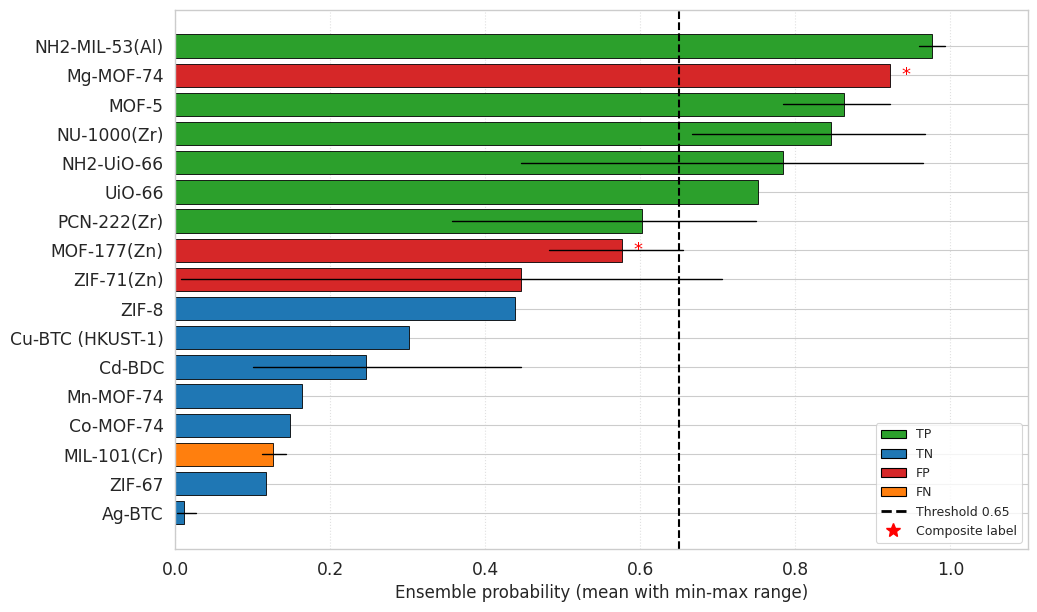

Figure saved: MOF_Dataset/Processed/bandgap_calc_vs_exp.pdf


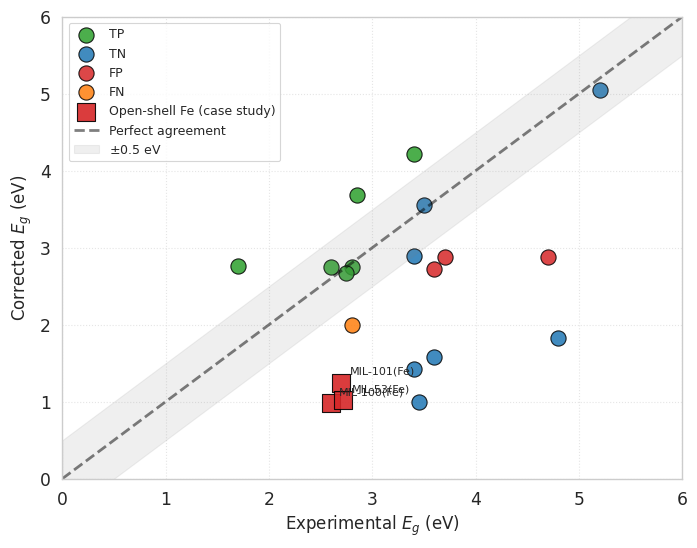

Figure saved: MOF_Dataset/Processed/scissor_family_robustness.pdf


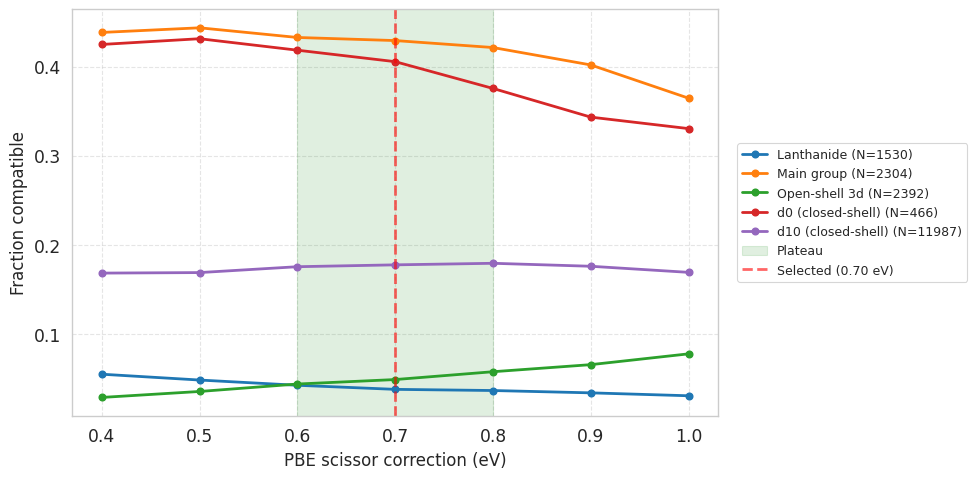

Figure saved: MOF_Dataset/Processed/baseline_comparison_closed_shell.pdf


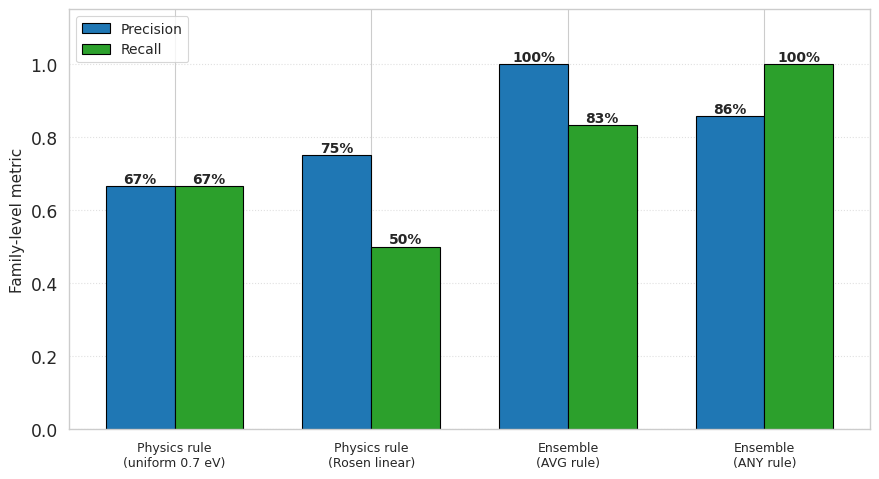

In [36]:

color_map = {
    'TP': '#2ca02c', 'TN': '#1f77b4',
    'FP': '#d62728', 'FN': '#ff7f0e', 'NA': '#999999',
}

# Figure 1: Family-level prediction probabilities
fig, ax = plt.subplots(figsize=(11, 7))
plot_df = family_df.sort_values('Avg_Prob', ascending=True)
colors = plot_df['Outcome_Any'].map(color_map)
ax.barh(plot_df['System'], plot_df['Avg_Prob'], color=colors,
        edgecolor='black', linewidth=0.6)
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.plot([row['Min_Prob'], row['Max_Prob']], [i, i], color='black', linewidth=1.0)
    if not row['Safe_Label']:
        ax.text(row['Avg_Prob'] + 0.015, i, '*', va='center',
                fontsize=13, color='red')
ax.axvline(0.65, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Ensemble probability (mean with min-max range)', fontsize=12)
ax.set_xlim(0, 1.10)
ax.grid(True, axis='x', linestyle=':', alpha=0.6)
legend_elements = [
    mpatches.Patch(facecolor='#2ca02c', edgecolor='black', label='TP'),
    mpatches.Patch(facecolor='#1f77b4', edgecolor='black', label='TN'),
    mpatches.Patch(facecolor='#d62728', edgecolor='black', label='FP'),
    mpatches.Patch(facecolor='#ff7f0e', edgecolor='black', label='FN'),
    plt.Line2D([0], [0], color='black', linestyle='--', label='Threshold 0.65'),
    plt.Line2D([0], [0], marker='*', color='red', linestyle='',
               markersize=10, label='Composite label'),
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=9)
save_and_show(fig, "validation_family_probabilities", Config.OUTPUT_DIR)

# Figure 2: Calculated vs experimental band gaps
fig, ax = plt.subplots(figsize=(8, 6))
for outcome_lbl, color in color_map.items():
    if outcome_lbl == 'NA':
        continue
    sub = family_df[family_df['Outcome_Any'] == outcome_lbl]
    if len(sub) > 0:
        ax.scatter(sub['Eg_Exp'], sub['Eg_Calc'],
                   s=120, c=color, alpha=0.85, edgecolor='black',
                   label=outcome_lbl)
if len(fe_summary) > 0:
    fe_plot = fe_summary.reset_index()
    ax.scatter(fe_plot['Eg_Exp'], fe_plot['Eg_Calc'],
               s=180, c='#d62728', alpha=0.9, edgecolor='black',
               marker='s', label='Open-shell Fe (case study)')
    for _, row in fe_plot.iterrows():
        ax.annotate(row['System'], (row['Eg_Exp'], row['Eg_Calc']),
                    xytext=(6, 6), textcoords='offset points', fontsize=8)
lims = [0, 6]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect agreement')
ax.fill_between(lims, [l - 0.5 for l in lims], [l + 0.5 for l in lims],
                color='gray', alpha=0.12, label=r'$\pm 0.5$ eV')
ax.set_xlabel(r'Experimental $E_g$ (eV)', fontsize=12)
ax.set_ylabel(r'Corrected $E_g$ (eV)', fontsize=12)
ax.set_xlim(0, 6); ax.set_ylim(0, 6)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
save_and_show(fig, "bandgap_calc_vs_exp", Config.OUTPUT_DIR)

# Figure 3: Scissor robustness by family
fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette("tab10", n_colors=len(pivot.index))
for i, fam in enumerate(pivot.index):
    n_fam = int(fam_scissor[fam_scissor['Family'] == fam]['N_Family'].iloc[0])
    ax.plot(pivot.columns, pivot.loc[fam], marker='o',
            label=f"{fam} (N={n_fam})", linewidth=2, color=palette[i])
ax.axvspan(0.60, 0.80, color='green', alpha=0.12, label='Plateau')
ax.axvline(0.70, color='red', linestyle='--', alpha=0.6, label='Selected (0.70 eV)')
ax.set_xlabel('PBE scissor correction (eV)')
ax.set_ylabel('Fraction compatible')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
save_and_show(fig, "scissor_family_robustness", Config.OUTPUT_DIR)

# Figure 4: Baseline comparison bar chart
fig, ax = plt.subplots(figsize=(9, 5))
methods = ['Physics rule\n(uniform 0.7 eV)', 'Physics rule\n(Rosen linear)',
           'Ensemble\n(AVG rule)', 'Ensemble\n(ANY rule)']
prec_values = []
recall_values = []
for col in ['PhysRule_Uniform', 'PhysRule_Rosen', 'Ensemble_Avg', 'Ensemble_Any']:
    tp, tn, fp, fn = safe_confusion(closed_baseline['Label_Lit'], closed_baseline[col])
    prec_values.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
    recall_values.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
x = np.arange(len(methods))
width = 0.35
b1 = ax.bar(x - width/2, prec_values, width, label='Precision',
            color='#1f77b4', edgecolor='black')
b2 = ax.bar(x + width/2, recall_values, width, label='Recall',
            color='#2ca02c', edgecolor='black')
for bar, v in zip(b1, prec_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{v:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, v in zip(b2, recall_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{v:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=9)
ax.set_ylabel('Family-level metric', fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper left', frameon=True)
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
save_and_show(fig, "baseline_comparison_closed_shell", Config.OUTPUT_DIR)

In [37]:
# MOF-5 GAP OVERSHOOT DIAGNOSTIC

print("OF-5 BAND-GAP OVERSHOOT DIAGNOSTIC")

mof5 = family_df[family_df['System'] == 'MOF-5']
if len(mof5) > 0:
    mof5_eg_calc = float(mof5['Eg_Calc'].iloc[0])
    mof5_eg_exp  = float(mof5['Eg_Exp'].iloc[0])
    mof5_error   = mof5_eg_calc - mof5_eg_exp
    mof5_prob    = float(mof5['Avg_Prob'].iloc[0])
    mof5_label   = int(mof5['Label_Lit'].iloc[0])
    mof5_pred_any = int(mof5['Pred_Any'].iloc[0])

    # Compare against other Zn-MOFs in the validation set
    zn_others = family_df[
        (family_df['Metal'] == 'Zn') & (family_df['System'] != 'MOF-5')
    ].copy()
    zn_others['Error_eV'] = zn_others['Eg_Calc'] - zn_others['Eg_Exp']

    print(f"\n  MOF-5:")
    print(f"    Corrected Eg  : {mof5_eg_calc:.2f} eV")
    print(f"    Experimental  : {mof5_eg_exp:.2f} eV")
    print(f"    Gap offset    : {mof5_error:+.2f} eV")
    print(f"    Ensemble prob : {mof5_prob:.3f}")
    print(f"    Lit label     : {mof5_label} (active)")
    print(f"    Prediction    : {'TP' if mof5_pred_any==1 and mof5_label==1 else 'other'}")

    print(f"\n  Zn-MOFs across the validation set ({len(zn_others) + 1} families):")
    print(f"    MOF-5                Eg_calc={mof5_eg_calc:.2f}  "
          f"Eg_exp={mof5_eg_exp:.2f}  err={mof5_error:+.2f} eV")
    for _, row in zn_others.iterrows():
        print(f"    {row['System']:<20} Eg_calc={row['Eg_Calc']:.2f}  "
              f"Eg_exp={row['Eg_Exp']:.2f}  err={row['Error_eV']:+.2f} eV")

    mof5_audit = pd.DataFrame([{
        'System': 'MOF-5',
        'Eg_calc_eV': round(mof5_eg_calc, 2),
        'Eg_exp_eV':  round(mof5_eg_exp, 2),
        'Gap_offset_eV': round(mof5_error, 2),
        'Ensemble_prob': round(mof5_prob, 3),
        'Lit_label': mof5_label,
        'Classified_correctly': bool(mof5_pred_any == mof5_label),
    }])
    mof5_audit.to_csv(Config.OUTPUT_DIR / "mof5_gap_offset_audit.csv", index=False)
    display(mof5_audit)

OF-5 BAND-GAP OVERSHOOT DIAGNOSTIC

  MOF-5:
    Corrected Eg  : 4.22 eV
    Experimental  : 3.40 eV
    Gap offset    : +0.82 eV
    Ensemble prob : 0.863
    Lit label     : 1 (active)
    Prediction    : TP

  Zn-MOFs across the validation set (4 families):
    MOF-5                Eg_calc=4.22  Eg_exp=3.40  err=+0.82 eV
    MOF-177(Zn)          Eg_calc=2.87  Eg_exp=3.70  err=-0.83 eV
    ZIF-71(Zn)           Eg_calc=2.88  Eg_exp=4.70  err=-1.82 eV
    ZIF-8                Eg_calc=5.05  Eg_exp=5.20  err=-0.15 eV


,System,Eg_calc_eV,Eg_exp_eV,Gap_offset_eV,Ensemble_prob,Lit_label,Classified_correctly
0,MOF-5,4.22,3.4,0.82,0.863,1,True


In [38]:
# PCN-222 BORDERLINE-CASE AUDIT (ANY vs AVG RULE)

print("PCN-222 BORDERLINE CASE (ANY vs AVG rule)")

pcn_struct = val_results[val_results['System'] == 'PCN-222(Zr)'].copy()
if len(pcn_struct) > 0:
    probs     = pcn_struct['ML_Prob'].values
    n_above   = int((probs >= 0.65).sum())
    n_below   = int((probs <  0.65).sum())
    mean_prob = float(probs.mean())

    print(f"\n  PCN-222(Zr) per-structure probabilities:")
    for _, row in pcn_struct.iterrows():
        status = 'above 0.65' if row['ML_Prob'] >= 0.65 else 'below 0.65'
        print(f"    {row['Refcode_Clean']}  prob = {row['ML_Prob']:.3f}  ({status})")

    print(f"\n  Above threshold : {n_above}/{len(pcn_struct)}")
    print(f"  Below threshold : {n_below}/{len(pcn_struct)}")
    print(f"  Mean probability: {mean_prob:.3f}")
    print(f"  ANY rule (headline): {'TP (correctly recovered)' if n_above >= 1 else 'FN'}")
    print(f"  AVG rule (supplementary): {'TP' if mean_prob >= 0.65 else 'FN'}")

    pcn_audit = pd.DataFrame([{
        'System': 'PCN-222(Zr)',
        'N_structures': len(pcn_struct),
        'N_above_0.65': n_above,
        'N_below_0.65': n_below,
        'Mean_prob':  round(mean_prob, 3),
        'Min_prob':   round(float(probs.min()), 3),
        'Max_prob':   round(float(probs.max()), 3),
        'ANY_outcome': 'TP' if n_above >= 1 else 'FN',
        'AVG_outcome': 'TP' if mean_prob >= 0.65 else 'FN',
        'Interpretation': (
            'Two of three sampled PCN-222 structures exceed the 0.65 '
            'threshold (max prob 0.750), and the headline ANY rule '
            'correctly recovers this known-active porphyrin framework. '
            'The per-structure spread reflects the threshold sensitivity '
            'that arises when metal-centered porphyrin transitions are '
            'represented through compositional descriptors, and motivates '
            'reporting the ANY rule as the headline metric for a '
            'recall-first screening workflow.'
        ),
    }])
    pcn_audit.to_csv(Config.OUTPUT_DIR / "pcn222_borderline_audit.csv", index=False)
    display(pcn_audit)

PCN-222 BORDERLINE CASE (ANY vs AVG rule)

  PCN-222(Zr) per-structure probabilities:
    qmof-7c26331  prob = 0.357  (below 0.65)
    qmof-ad36e2f  prob = 0.750  (above 0.65)
    qmof-646c173  prob = 0.699  (above 0.65)

  Above threshold : 2/3
  Below threshold : 1/3
  Mean probability: 0.602
  ANY rule (headline): TP (correctly recovered)
  AVG rule (supplementary): FN


,System,N_structures,N_above_0.65,N_below_0.65,Mean_prob,Min_prob,Max_prob,ANY_outcome,AVG_outcome,Interpretation
0,PCN-222(Zr),3,2,1,0.602,0.357,0.75,TP,FN,Two of three sampled PCN-222 structures exceed...


In [39]:
# HEADLINE RULE SELECTION: ANY vs AVG (recall-first rationale)

rule_comparison = []
for rule_col, rule_name in [('Pred_Any', 'ANY (headline)'),
                             ('Pred_Avg', 'AVG (supplementary)')]:
    m = fam_metrics(closed_safe, rule_col, 'Label_Lit')
    rule_comparison.append({
        'Rule': rule_name,
        'TP': m['TP'], 'TN': m['TN'], 'FP': m['FP'], 'FN': m['FN'],
        'Precision': m['Precision'],
        'Recall':    m['Recall'],
        'Accuracy':  m['Accuracy'],
        'False_positives_named': ', '.join(
            closed_safe[(closed_safe[rule_col]==1) &
                        (closed_safe['Label_Lit']==0)]['System'].tolist()
        ) or 'none',
        'False_negatives_named': ', '.join(
            closed_safe[(closed_safe[rule_col]==0) &
                        (closed_safe['Label_Lit']==1)]['System'].tolist()
        ) or 'none',
    })

rule_cmp_df = pd.DataFrame(rule_comparison)
print("\nHead-to-head rule comparison (closed-shell safe-label, N=11):")
display(rule_cmp_df)
rule_cmp_df.to_csv(Config.OUTPUT_DIR / "rule_comparison_any_vs_avg.csv", index=False)


Head-to-head rule comparison (closed-shell safe-label, N=11):


,Rule,TP,TN,FP,FN,Precision,Recall,Accuracy,False_positives_named,False_negatives_named
0,ANY (headline),6,4,1,0,"85.7% [48.7%, 97.4%]","100.0% [61.0%, 100.0%]","90.9% [62.3%, 98.4%]",ZIF-71(Zn),none
1,AVG (supplementary),5,5,0,1,"100.0% [56.6%, 100.0%]","83.3% [43.6%, 97.0%]","90.9% [62.3%, 98.4%]",none,PCN-222(Zr)


In [42]:
print("OPEN-SHELL CASE STUDY")

os_val = extended_os.copy()

if len(fe_summary) > 0:
    fe_labels = pd.DataFrame({
        'System': fe_summary.index,
        'Metal':  fe_summary['Metal'].values,
        'Label_Lit': 1,
        'Avg_Prob': fe_summary['Avg_Prob'].values,
        'Eg_Calc':  fe_summary['Eg_Calc'].values,
        'Eg_Exp':   fe_summary['Eg_Exp'].values,
        'Abs_Error_eV': fe_summary['Abs_Error_eV'].values,
        'Pred_Avg': (fe_summary['Avg_Prob'] >= 0.65).astype(int).values,
    })
else:
    fe_labels = pd.DataFrame()

open_shell_all = pd.concat([
    os_val[['System','Metal','Label_Lit','Avg_Prob','Eg_Calc','Eg_Exp',
            'Abs_Error_eV','Pred_Avg']],
    fe_labels,
], ignore_index=True)

os_active = open_shell_all[open_shell_all['Label_Lit'] == 1]
os_inactive = open_shell_all[open_shell_all['Label_Lit'] == 0]

n_os_active = len(os_active)
n_os_active_recovered = int((os_active['Pred_Avg'] == 1).sum())
n_os_inactive = len(os_inactive)
n_os_inactive_rejected = int((os_inactive['Pred_Avg'] == 0).sum())

os_mean_gap_err = open_shell_all['Abs_Error_eV'].mean()

# Correctly ordered SHAP attribution (bug fix: was "3 of 2")
_n_total_audited = len(audit_rows) if 'audit_rows' in dir() else 0
_n_chem_dom      = n_chem if 'n_chem' in dir() else 0

print(f"Total Active Open-Shell:   {n_os_active}")
if n_os_active > 0:
    print(f" -> Recovered (Pred = 1):  {n_os_active_recovered} ({(n_os_active_recovered / n_os_active) * 100:.1f}%)")

print(f"\nTotal Inactive Open-Shell: {n_os_inactive}")
if n_os_inactive > 0:
    print(f" -> Rejected (Pred = 0):   {n_os_inactive_rejected} ({(n_os_inactive_rejected / n_os_inactive) * 100:.1f}%)")

print(f"\nMean Gap Abs Error:        {os_mean_gap_err:.3f} eV")

# Print audit stats if they were found in the directory
if _n_total_audited > 0:
    print(f"\nSHAP Audit Summary:")
    print(f" -> Total Audited Rows:    {_n_total_audited}")
    print(f" -> Chemically Dominated:  {_n_chem_dom}")

OPEN-SHELL CASE STUDY
Total Active Open-Shell:   4
 -> Recovered (Pred = 1):  0 (0.0%)

Total Inactive Open-Shell: 3
 -> Rejected (Pred = 0):   3 (100.0%)

Mean Gap Abs Error:        1.855 eV

SHAP Audit Summary:
 -> Total Audited Rows:    2
 -> Chemically Dominated:  3


In [41]:
# ZIF-71 AUDIT: SOLE FALSE POSITIVE UNDER ANY RULE


zif71 = val_results[val_results['System'] == 'ZIF-71(Zn)'].copy()
if len(zif71) > 0:
    probs    = zif71['ML_Prob'].values
    n_above  = int((probs >= 0.65).sum())
    n_below  = int((probs <  0.65).sum())
    mean_p   = float(probs.mean())
    eg_calc  = float(zif71['Eg_Corrected'].mean())
    eg_exp   = 4.7  # Experimental UV-only gap (Park 2006 chemistry family)

    print(f"\n  ZIF-71(Zn) per-structure probabilities:")
    for _, row in zif71.iterrows():
        status = 'above 0.65' if row['ML_Prob'] >= 0.65 else 'below 0.65'
        print(f"    {row['Refcode_Clean']}  prob = {row['ML_Prob']:.3f}  ({status})")

    print(f"\n  Above threshold : {n_above}/{len(zif71)}")
    print(f"  Below threshold : {n_below}/{len(zif71)}")
    print(f"  Mean probability: {mean_p:.3f}")
    print(f"  Corrected Eg    : {eg_calc:.2f} eV")
    print(f"  Experimental Eg : {eg_exp:.2f} eV (UV-only, fluorinated imidazolate)")
    print(f"  Gap offset      : {eg_calc - eg_exp:+.2f} eV")
    print(f"  ANY rule outcome: FP (one borderline structure above threshold)")
    print(f"  AVG rule outcome: TN (mean below threshold)")

    zif71_audit = pd.DataFrame([{
        'System': 'ZIF-71(Zn)',
        'N_structures': len(zif71),
        'N_above_0.65': n_above,
        'N_below_0.65': n_below,
        'Mean_prob':  round(mean_p, 3),
        'Max_prob':   round(float(probs.max()), 3),
        'Min_prob':   round(float(probs.min()), 3),
        'Eg_calc_eV': round(eg_calc, 2),
        'Eg_exp_eV':  eg_exp,
        'Gap_offset_eV': round(eg_calc - eg_exp, 2),
        'ANY_outcome': 'FP',
        'AVG_outcome': 'TN',

    }])
    zif71_audit.to_csv(Config.OUTPUT_DIR / "zif71_fp_audit.csv", index=False)
    display(zif71_audit)


  ZIF-71(Zn) per-structure probabilities:
    qmof-a442a79  prob = 0.008  (below 0.65)
    qmof-c1bc002  prob = 0.624  (below 0.65)
    qmof-7c9951b  prob = 0.706  (above 0.65)

  Above threshold : 1/3
  Below threshold : 2/3
  Mean probability: 0.446
  Corrected Eg    : 2.88 eV
  Experimental Eg : 4.70 eV (UV-only, fluorinated imidazolate)
  Gap offset      : -1.82 eV
  ANY rule outcome: FP (one borderline structure above threshold)
  AVG rule outcome: TN (mean below threshold)


,System,N_structures,N_above_0.65,N_below_0.65,Mean_prob,Max_prob,Min_prob,Eg_calc_eV,Eg_exp_eV,Gap_offset_eV,ANY_outcome,AVG_outcome
0,ZIF-71(Zn),3,1,2,0.446,0.706,0.008,2.88,4.7,-1.82,FP,TN
